In [1]:
# ============================================================
# EXPERIMENT 7
# End-to-End Study of Autoencoders, Convolutional Autoencoders,
# Denoising Autoencoders and Variational Autoencoders
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model

from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

import time
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 70)
print("EXPERIMENT 7: AUTOENCODERS")
print("=" * 70)

print("\nTensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)

# Check GPU availability
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU Available      : YES")
    print("GPU Device         :", gpus[0])
else:
    print("GPU Available      : NO")

print("=" * 70)

EXPERIMENT 7: AUTOENCODERS

TensorFlow Version : 2.20.0
NumPy Version      : 2.1.3
GPU Available      : NO


In [2]:
# ============================================================
# CELL 2: LOAD MNIST DATASET
# ============================================================

print("\nLoading MNIST dataset...")

(x_train_full, y_train_full), (x_test_full, y_test_full) = \
    keras.datasets.mnist.load_data()

print("\nOriginal Dataset Information")
print("-" * 50)
print("Training images :", x_train_full.shape)
print("Training labels :", y_train_full.shape)
print("Test images     :", x_test_full.shape)
print("Test labels     :", y_test_full.shape)

print("\nPixel value range before normalization:")
print("Minimum pixel value:", x_train_full.min())
print("Maximum pixel value:", x_train_full.max())


Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Original Dataset Information
--------------------------------------------------
Training images : (60000, 28, 28)
Training labels : (60000,)
Test images     : (10000, 28, 28)
Test labels     : (10000,)

Pixel value range before normalization:
Minimum pixel value: 0
Maximum pixel value: 255


In [3]:
# ============================================================
# CELL 3: SELECT SUBSET AND PREPROCESS DATA
# ============================================================

TRAIN_SIZE = 10000
TEST_SIZE = 2000

# Select recommended laboratory subset
x_train = x_train_full[:TRAIN_SIZE]
y_train = y_train_full[:TRAIN_SIZE]

x_test = x_test_full[:TEST_SIZE]
y_test = y_test_full[:TEST_SIZE]

# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension for convolutional models
x_train_cnn = np.expand_dims(x_train, axis=-1)
x_test_cnn = np.expand_dims(x_test, axis=-1)

print("=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)

print("\nSelected Dataset")
print("-" * 50)
print("Training samples :", len(x_train))
print("Testing samples  :", len(x_test))

print("\nFC-Autoencoder Input Shape")
print("Training:", x_train.shape)
print("Testing :", x_test.shape)

print("\nCNN-Autoencoder Input Shape")
print("Training:", x_train_cnn.shape)
print("Testing :", x_test_cnn.shape)

print("\nNormalized Pixel Range")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

print("\nLabels are NOT used as reconstruction targets.")
print("Target for each model = original input image")

print("=" * 70)

DATA PREPROCESSING

Selected Dataset
--------------------------------------------------
Training samples : 10000
Testing samples  : 2000

FC-Autoencoder Input Shape
Training: (10000, 28, 28)
Testing : (2000, 28, 28)

CNN-Autoencoder Input Shape
Training: (10000, 28, 28, 1)
Testing : (2000, 28, 28, 1)

Normalized Pixel Range
Minimum: 0.0
Maximum: 1.0

Labels are NOT used as reconstruction targets.
Target for each model = original input image


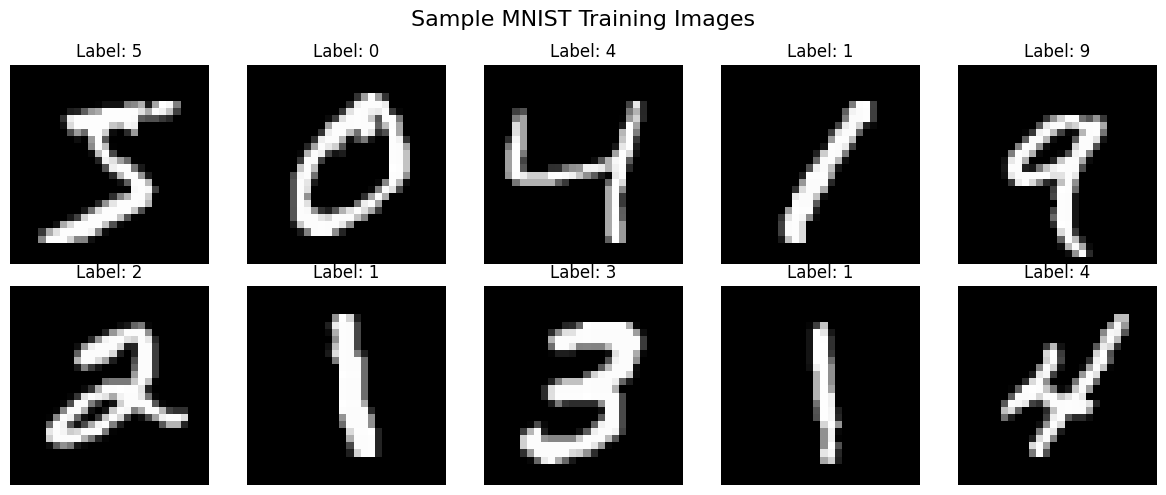


Sample Image Information
--------------------------------------------------
Image shape       : (28, 28)
Image data type   : float32
Pixel range       : 0.0 to 1.0
Number of classes : 10
Classes           : [0 1 2 3 4 5 6 7 8 9]


In [4]:
# ============================================================
# CELL 4: VISUALIZE SAMPLE MNIST IMAGES
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.suptitle("Sample MNIST Training Images", fontsize=16)
plt.tight_layout()
plt.show()

print("\nSample Image Information")
print("-" * 50)
print("Image shape       :", x_train[0].shape)
print("Image data type   :", x_train.dtype)
print("Pixel range       :", f"{x_train[0].min():.1f} to {x_train[0].max():.1f}")
print("Number of classes :", len(np.unique(y_train)))
print("Classes           :", np.unique(y_train))

In [5]:
# ============================================================
# CELL 5: PREPARE DATA FOR FULLY CONNECTED AUTOENCODER
# ============================================================

# Flatten 28 x 28 images into 784-dimensional vectors
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print("=" * 70)
print("FULLY CONNECTED AUTOENCODER - DATA PREPARATION")
print("=" * 70)

print("\nOriginal image shape :", x_train.shape)
print("Flattened image shape:", x_train_flat.shape)

print("\nTraining input shape :", x_train_flat.shape)
print("Testing input shape  :", x_test_flat.shape)

print("\nEach image:")
print("28 × 28 =", 28 * 28, "pixels")

print("\nPixel value range:")
print("Minimum:", x_train_flat.min())
print("Maximum:", x_train_flat.max())

print("=" * 70)

FULLY CONNECTED AUTOENCODER - DATA PREPARATION

Original image shape : (10000, 28, 28)
Flattened image shape: (10000, 784)

Training input shape : (10000, 784)
Testing input shape  : (2000, 784)

Each image:
28 × 28 = 784 pixels

Pixel value range:
Minimum: 0.0
Maximum: 1.0


In [6]:
# ============================================================
# CELL 6: BUILD FULLY CONNECTED AUTOENCODER
# ============================================================

# Input layer
fc_input = keras.Input(shape=(784,), name="input_784")

# ---------------- ENCODER ----------------
fc_x = layers.Dense(128, activation="relu", name="encoder_dense_128")(fc_input)
fc_x = layers.Dense(32, activation="relu", name="encoder_dense_32")(fc_x)

# Latent representation
fc_latent = layers.Dense(16, activation="relu", name="latent_16")(fc_x)

# ---------------- DECODER ----------------
fc_x = layers.Dense(32, activation="relu", name="decoder_dense_32")(fc_latent)
fc_x = layers.Dense(128, activation="relu", name="decoder_dense_128")(fc_x)

# Output reconstruction
fc_output = layers.Dense(
    784,
    activation="sigmoid",
    name="output_784"
)(fc_x)

# Create model
fc_autoencoder = keras.Model(
    fc_input,
    fc_output,
    name="Fully_Connected_Autoencoder"
)

# Compile
fc_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

print("=" * 70)
print("FULLY CONNECTED AUTOENCODER")
print("=" * 70)

fc_autoencoder.summary()

FULLY CONNECTED AUTOENCODER


Model: "Fully_Connected_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_784 (InputLayer)          │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_128 (Dense)       │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_32 (Dense)        │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_16 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_32 (Dense)        │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_128 (Dense)       │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_784 (Dense)              │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ============================================================
# CELL 7: TRAIN FULLY CONNECTED AUTOENCODER
# ============================================================

print("=" * 70)
print("TRAINING FULLY CONNECTED AUTOENCODER")
print("=" * 70)

start_time_fc = time.time()

fc_history = fc_autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_flat, x_test_flat),
    shuffle=True,
    verbose=1
)

fc_training_time = time.time() - start_time_fc

print("\n" + "=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)

print(f"Training time: {fc_training_time:.2f} seconds")
print(f"Final training loss   : {fc_history.history['loss'][-1]:.6f}")
print(f"Final validation loss : {fc_history.history['val_loss'][-1]:.6f}")

TRAINING FULLY CONNECTED AUTOENCODER
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3336 - val_loss: 0.2491
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2371 - val_loss: 0.2137
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1977 - val_loss: 0.1870
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1796 - val_loss: 0.1736
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1676 - val_loss: 0.1644
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1597 - val_loss: 0.1579
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1539 - val_loss: 0.1526
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1490 - val_loss: 0.1486
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1449 - val_loss: 0.1450
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1410 - val_loss: 0.1413
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1375 - val_loss: 0.1386
Epoch 12/20
79/79 ━━━━━━━━

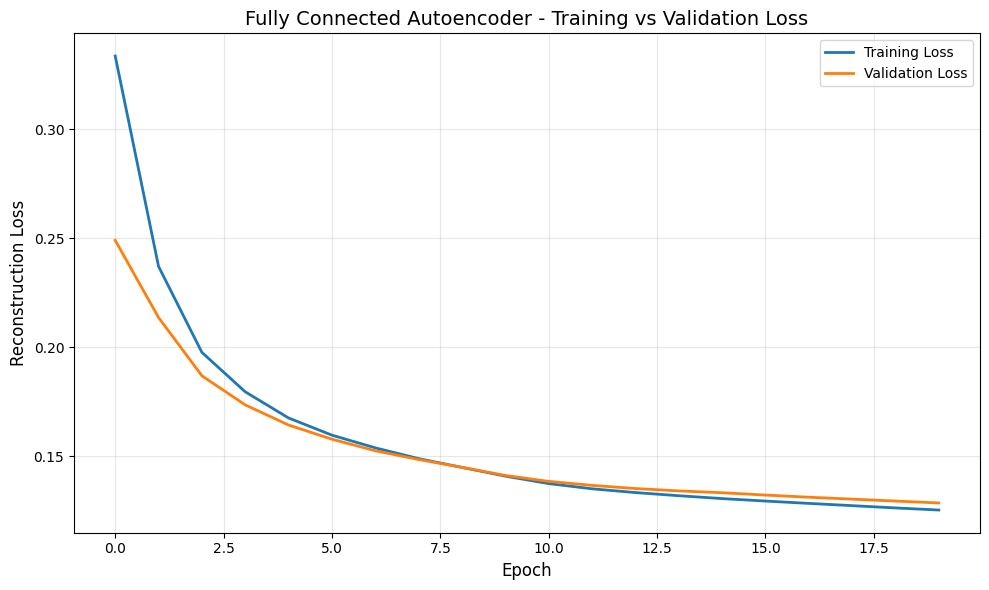


TRAINING ANALYSIS
Initial Training Loss   : 0.333636
Final Training Loss     : 0.125405
Initial Validation Loss : 0.249100
Final Validation Loss   : 0.128652

Observation: Training loss decreased during training.
Observation: Validation loss also decreased.
Observation: Training and validation losses are relatively close.


In [8]:
# ============================================================
# CELL 8: TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    fc_history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    fc_history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Reconstruction Loss", fontsize=12)
plt.title(
    "Fully Connected Autoencoder - Training vs Validation Loss",
    fontsize=14
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Informative analysis
train_losses = fc_history.history["loss"]
val_losses = fc_history.history["val_loss"]

print("\n" + "=" * 70)
print("TRAINING ANALYSIS")
print("=" * 70)

print(f"Initial Training Loss   : {train_losses[0]:.6f}")
print(f"Final Training Loss     : {train_losses[-1]:.6f}")
print(f"Initial Validation Loss : {val_losses[0]:.6f}")
print(f"Final Validation Loss   : {val_losses[-1]:.6f}")

if train_losses[-1] < train_losses[0]:
    print("\nObservation: Training loss decreased during training.")

if val_losses[-1] < val_losses[0]:
    print("Observation: Validation loss also decreased.")

if abs(train_losses[-1] - val_losses[-1]) < 0.05:
    print("Observation: Training and validation losses are relatively close.")
else:
    print("Observation: There is a noticeable gap between training and validation loss.")

print("=" * 70)

In [9]:
# ============================================================
# CELL 9: GENERATE FC-AE RECONSTRUCTIONS
# ============================================================

print("=" * 70)
print("GENERATING RECONSTRUCTIONS")
print("=" * 70)

# Reconstruct test images
fc_reconstructed_flat = fc_autoencoder.predict(
    x_test_flat,
    verbose=0
)

# Convert reconstructed vectors back to 28 x 28 images
fc_reconstructed = fc_reconstructed_flat.reshape(-1, 28, 28)

print("Original test images      :", x_test.shape)
print("Reconstructed images      :", fc_reconstructed.shape)

print("\nReconstruction pixel range:")
print("Minimum:", fc_reconstructed.min())
print("Maximum:", fc_reconstructed.max())

print("\nReconstruction generation completed successfully.")
print("=" * 70)

GENERATING RECONSTRUCTIONS
Original test images      : (2000, 28, 28)
Reconstructed images      : (2000, 28, 28)

Reconstruction pixel range:
Minimum: 4.42537e-31
Maximum: 0.9998376

Reconstruction generation completed successfully.


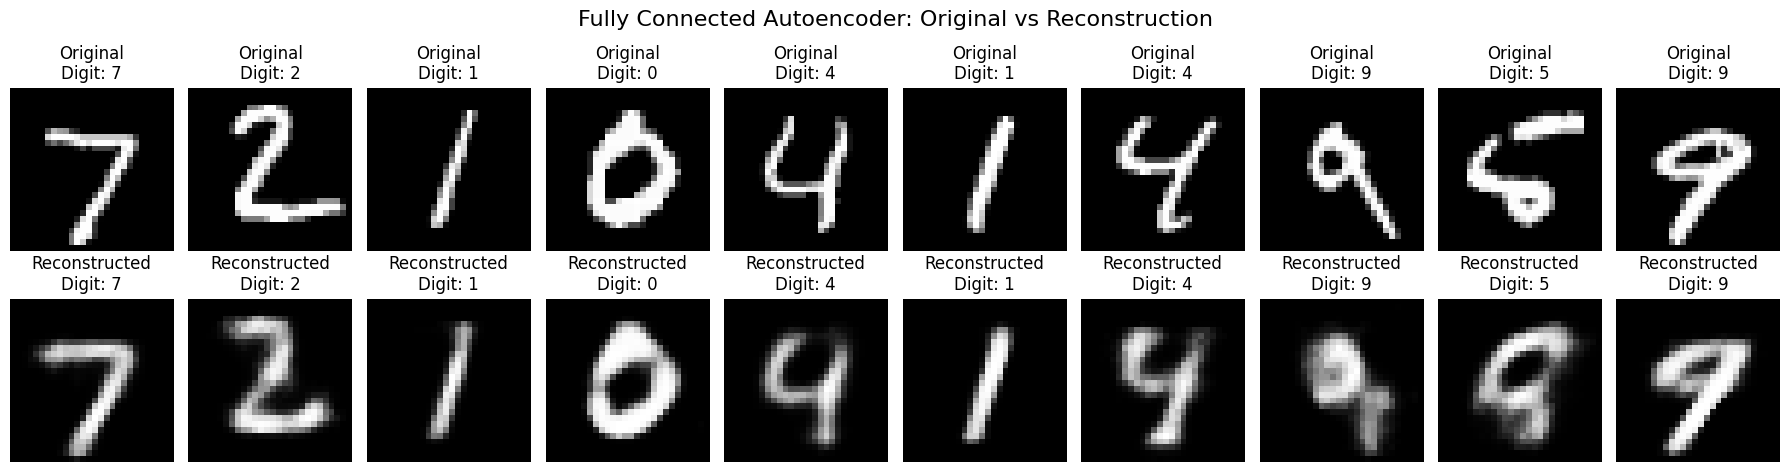


Displayed 10 test images.
Top row    : Original images
Bottom row : Reconstructed images


In [10]:
# ============================================================
# CELL 10: ORIGINAL VS RECONSTRUCTED IMAGES
# ============================================================

NUM_IMAGES = 10

fig, axes = plt.subplots(2, NUM_IMAGES, figsize=(18, 5))

for i in range(NUM_IMAGES):

    # Original image
    axes[0, i].imshow(x_test[i], cmap="gray")
    axes[0, i].set_title(f"Original\nDigit: {y_test[i]}")
    axes[0, i].axis("off")

    # Reconstructed image
    axes[1, i].imshow(fc_reconstructed[i], cmap="gray")
    axes[1, i].set_title(f"Reconstructed\nDigit: {y_test[i]}")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("FC-AE", fontsize=12)

plt.suptitle(
    "Fully Connected Autoencoder: Original vs Reconstruction",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("\nDisplayed 10 test images.")
print("Top row    : Original images")
print("Bottom row : Reconstructed images")

In [11]:
# ============================================================
# CELL 11: FC-AE RECONSTRUCTION METRICS
# ============================================================

print("=" * 70)
print("FULLY CONNECTED AUTOENCODER - TEST METRICS")
print("=" * 70)

# ------------------------------------------------------------
# MSE
# ------------------------------------------------------------
fc_mse = np.mean(
    (x_test - fc_reconstructed) ** 2
)

# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------
fc_mae = np.mean(
    np.abs(x_test - fc_reconstructed)
)

# ------------------------------------------------------------
# SSIM
# ------------------------------------------------------------
fc_ssim_values = []

for i in range(len(x_test)):
    score = ssim(
        x_test[i],
        fc_reconstructed[i],
        data_range=1.0
    )
    fc_ssim_values.append(score)

fc_mean_ssim = np.mean(fc_ssim_values)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nReconstruction Metrics")
print("-" * 50)

print(f"MSE  : {fc_mse:.6f}")
print(f"MAE  : {fc_mae:.6f}")
print(f"SSIM : {fc_mean_ssim:.6f}")

print("\nInterpretation:")
print("MSE  -> Average squared pixel reconstruction error")
print("MAE  -> Average absolute pixel reconstruction error")
print("SSIM -> Structural similarity between original and reconstructed images")

print("\nSSIM Range:")
print(f"Minimum SSIM : {np.min(fc_ssim_values):.6f}")
print(f"Maximum SSIM : {np.max(fc_ssim_values):.6f}")

print("=" * 70)

FULLY CONNECTED AUTOENCODER - TEST METRICS

Reconstruction Metrics
--------------------------------------------------
MSE  : 0.022515
MAE  : 0.059259
SSIM : 0.734634

Interpretation:
MSE  -> Average squared pixel reconstruction error
MAE  -> Average absolute pixel reconstruction error
SSIM -> Structural similarity between original and reconstructed images

SSIM Range:
Minimum SSIM : 0.314529
Maximum SSIM : 0.960657


In [12]:
# ============================================================
# CELL 12: PER-IMAGE RECONSTRUCTION ERROR
# ============================================================

# Calculate MSE for each individual test image
fc_image_errors = np.mean(
    (x_test - fc_reconstructed) ** 2,
    axis=(1, 2)
)

print("=" * 70)
print("PER-IMAGE RECONSTRUCTION ERROR")
print("=" * 70)

print(f"Number of test images : {len(fc_image_errors)}")
print(f"Minimum error         : {fc_image_errors.min():.6f}")
print(f"Maximum error         : {fc_image_errors.max():.6f}")
print(f"Mean error            : {fc_image_errors.mean():.6f}")
print(f"Median error          : {np.median(fc_image_errors):.6f}")

print("\nFive images with highest reconstruction error:")

highest_error_indices = np.argsort(fc_image_errors)[-5:][::-1]

for rank, idx in enumerate(highest_error_indices, start=1):
    print(
        f"Rank {rank}: "
        f"Test Index = {idx}, "
        f"Digit = {y_test[idx]}, "
        f"MSE = {fc_image_errors[idx]:.6f}"
    )

print("=" * 70)

PER-IMAGE RECONSTRUCTION ERROR
Number of test images : 2000
Minimum error         : 0.001632
Maximum error         : 0.070605
Mean error            : 0.022515
Median error          : 0.021362

Five images with highest reconstruction error:
Rank 1: Test Index = 1782, Digit = 8, MSE = 0.070605
Rank 2: Test Index = 1017, Digit = 6, MSE = 0.065115
Rank 3: Test Index = 1758, Digit = 8, MSE = 0.064826
Rank 4: Test Index = 1170, Digit = 8, MSE = 0.063132
Rank 5: Test Index = 654, Digit = 5, MSE = 0.062868


In [13]:
# ============================================================
# CELL 13: BUILD CONVOLUTIONAL AUTOENCODER
# ============================================================

print("=" * 70)
print("BUILDING CONVOLUTIONAL AUTOENCODER")
print("=" * 70)

# Input
cae_input = keras.Input(
    shape=(28, 28, 1),
    name="input_28x28x1"
)

# ============================================================
# ENCODER
# ============================================================

cae_x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same",
    name="encoder_conv_32"
)(cae_input)

cae_x = layers.MaxPooling2D(
    (2, 2),
    padding="same",
    name="encoder_pool_1"
)(cae_x)

cae_x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same",
    name="encoder_conv_64"
)(cae_x)

cae_x = layers.MaxPooling2D(
    (2, 2),
    padding="same",
    name="encoder_pool_2"
)(cae_x)

# Latent feature representation
cae_latent = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same",
    name="latent_feature_map"
)(cae_x)

# ============================================================
# DECODER
# ============================================================

cae_x = layers.UpSampling2D(
    (2, 2),
    name="decoder_upsampling_1"
)(cae_latent)

cae_x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same",
    name="decoder_conv_32"
)(cae_x)

cae_x = layers.UpSampling2D(
    (2, 2),
    name="decoder_upsampling_2"
)(cae_x)

# Final reconstructed image
cae_output = layers.Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same",
    name="output_image"
)(cae_x)

# Create model
conv_autoencoder = keras.Model(
    cae_input,
    cae_output,
    name="Convolutional_Autoencoder"
)

# Compile
conv_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

print("\nConvolutional Autoencoder Summary")
print("-" * 70)

conv_autoencoder.summary()

BUILDING CONVOLUTIONAL AUTOENCODER

Convolutional Autoencoder Summary
----------------------------------------------------------------------


Model: "Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_28x28x1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_32 (Conv2D)        │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_1 (MaxPooling2D)   │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_64 (Conv2D)        │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_2 (MaxPooling2D)   │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_feature_map (Conv2D)     │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsampling_1            │ (None, 14, 14, 64)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_32 (Conv2D)        │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsampling_2            │ (None, 28, 28, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_image (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ============================================================
# CELL 14: TRAIN CONVOLUTIONAL AUTOENCODER
# ============================================================

print("=" * 70)
print("TRAINING CONVOLUTIONAL AUTOENCODER")
print("=" * 70)

start_time_cae = time.time()

cae_history = conv_autoencoder.fit(
    x_train_cnn,
    x_train_cnn,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_cnn, x_test_cnn),
    shuffle=True,
    verbose=1
)

cae_training_time = time.time() - start_time_cae

print("\n" + "=" * 70)
print("CAE TRAINING COMPLETED")
print("=" * 70)

print(f"Training time          : {cae_training_time:.2f} seconds")
print(f"Final training loss    : {cae_history.history['loss'][-1]:.6f}")
print(f"Final validation loss  : {cae_history.history['val_loss'][-1]:.6f}")

print("=" * 70)

TRAINING CONVOLUTIONAL AUTOENCODER
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 411ms/step - loss: 0.2245 - val_loss: 0.0994
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 409ms/step - loss: 0.0907 - val_loss: 0.0828
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 396ms/step - loss: 0.0821 - val_loss: 0.0789
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - loss: 0.0783 - val_loss: 0.0752
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 373ms/step - loss: 0.0764 - val_loss: 0.0738
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 373ms/step - loss: 0.0748 - val_loss: 0.0727
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 384ms/step - loss: 0.0737 - val_loss: 0.0717
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 393ms/step - loss: 0.0729 - val_loss: 0.0709
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 391ms/step - loss: 0.0722 - val_loss: 0.0703
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - loss: 0.0717 - val_loss: 0.0700
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - loss: 0.0712 - val_loss: 0.0696
Epoch 

In [15]:
# ============================================================
# CELL 16: CAE RECONSTRUCTION AND METRICS
# ============================================================

print("=" * 70)
print("CAE RECONSTRUCTION AND EVALUATION")
print("=" * 70)

# Generate reconstructions
cae_reconstructed = conv_autoencoder.predict(
    x_test_cnn,
    verbose=0
)

print("\nReconstruction shape:")
print("Original      :", x_test_cnn.shape)
print("Reconstructed :", cae_reconstructed.shape)

# Remove channel dimension for metric calculation
cae_reconstructed_2d = cae_reconstructed.squeeze(axis=-1)

# ------------------------------------------------------------
# MSE
# ------------------------------------------------------------
cae_mse = np.mean(
    (x_test - cae_reconstructed_2d) ** 2
)

# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------
cae_mae = np.mean(
    np.abs(x_test - cae_reconstructed_2d)
)

# ------------------------------------------------------------
# SSIM
# ------------------------------------------------------------
cae_ssim_values = []

for i in range(len(x_test)):

    score = ssim(
        x_test[i],
        cae_reconstructed_2d[i],
        data_range=1.0
    )

    cae_ssim_values.append(score)

cae_mean_ssim = np.mean(cae_ssim_values)

print("\n" + "-" * 50)
print("CAE TEST METRICS")
print("-" * 50)

print(f"MSE  : {cae_mse:.6f}")
print(f"MAE  : {cae_mae:.6f}")
print(f"SSIM : {cae_mean_ssim:.6f}")

print("=" * 70)

CAE RECONSTRUCTION AND EVALUATION

Reconstruction shape:
Original      : (2000, 28, 28, 1)
Reconstructed : (2000, 28, 28, 1)

--------------------------------------------------
CAE TEST METRICS
--------------------------------------------------
MSE  : 0.002584
MAE  : 0.015057
SSIM : 0.973730


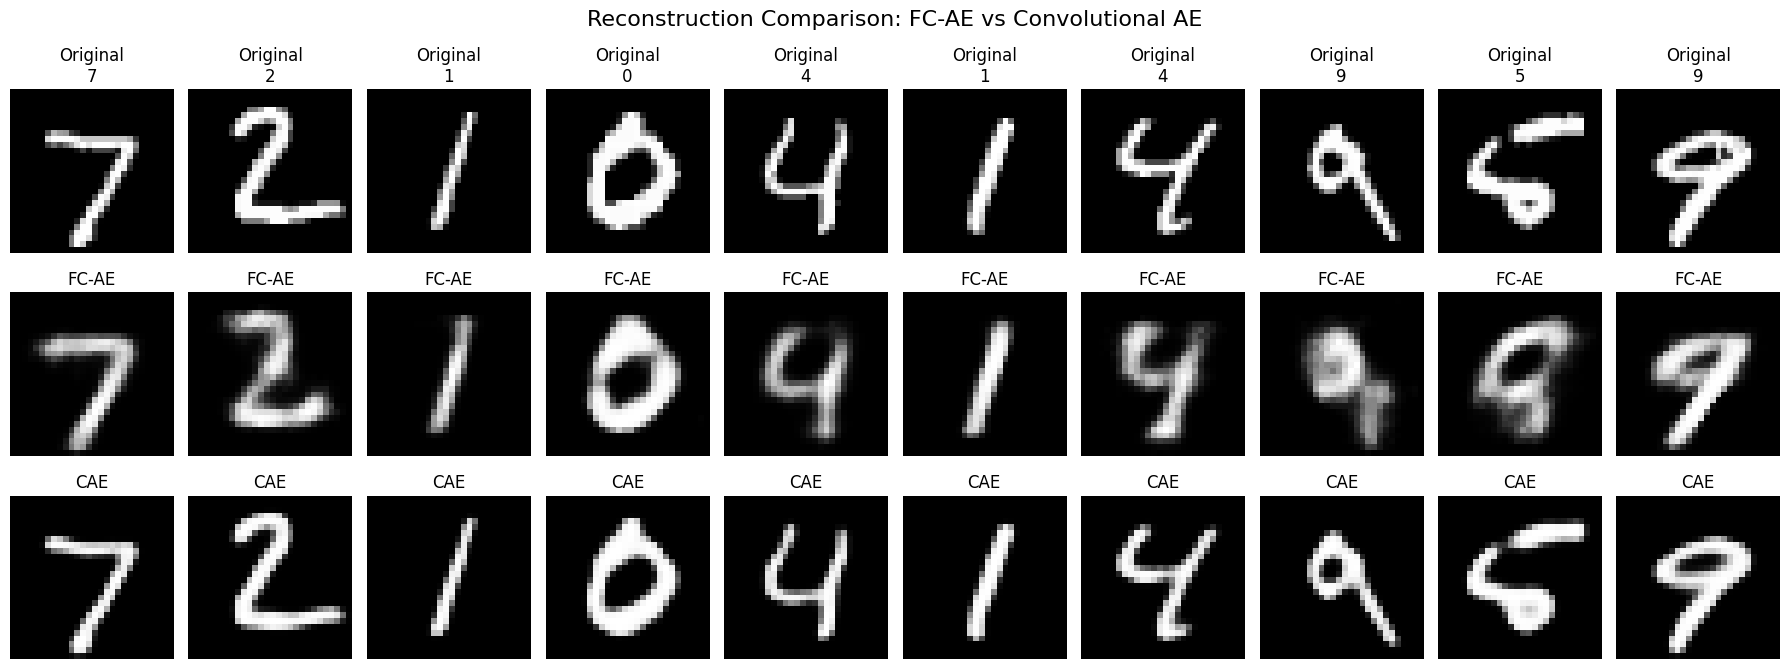

RECONSTRUCTION COMPARISON
Top row    : Original images
Middle row : Fully Connected Autoencoder
Bottom row : Convolutional Autoencoder

Compare the preservation of:
• Digit shape
• Stroke structure
• Fine details
• Blurring


In [16]:
# ============================================================
# CELL 17: FC-AE VS CAE RECONSTRUCTION COMPARISON
# ============================================================

NUM_IMAGES = 10

fig, axes = plt.subplots(
    3,
    NUM_IMAGES,
    figsize=(18, 7)
)

for i in range(NUM_IMAGES):

    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------
    axes[0, i].imshow(
        x_test[i],
        cmap="gray"
    )
    axes[0, i].set_title(
        f"Original\n{y_test[i]}"
    )
    axes[0, i].axis("off")

    # --------------------------------------------------------
    # FC-AE
    # --------------------------------------------------------
    axes[1, i].imshow(
        fc_reconstructed[i],
        cmap="gray"
    )
    axes[1, i].set_title("FC-AE")
    axes[1, i].axis("off")

    # --------------------------------------------------------
    # CAE
    # --------------------------------------------------------
    axes[2, i].imshow(
        cae_reconstructed_2d[i],
        cmap="gray"
    )
    axes[2, i].set_title("CAE")
    axes[2, i].axis("off")


axes[0, 0].set_ylabel(
    "Original",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "FC-AE",
    fontsize=12
)

axes[2, 0].set_ylabel(
    "CAE",
    fontsize=12
)

plt.suptitle(
    "Reconstruction Comparison: FC-AE vs Convolutional AE",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("=" * 70)
print("RECONSTRUCTION COMPARISON")
print("=" * 70)

print("Top row    : Original images")
print("Middle row : Fully Connected Autoencoder")
print("Bottom row : Convolutional Autoencoder")

print("\nCompare the preservation of:")
print("• Digit shape")
print("• Stroke structure")
print("• Fine details")
print("• Blurring")
print("=" * 70)

In [17]:
# ============================================================
# CELL 18: FC-AE VS CAE QUANTITATIVE COMPARISON
# ============================================================

fc_params = fc_autoencoder.count_params()
cae_params = conv_autoencoder.count_params()

comparison_df = pd.DataFrame({
    "Model": [
        "Fully Connected AE",
        "Convolutional AE"
    ],
    "MSE": [
        fc_mse,
        cae_mse
    ],
    "MAE": [
        fc_mae,
        cae_mae
    ],
    "SSIM": [
        fc_mean_ssim,
        cae_mean_ssim
    ],
    "Parameters": [
        fc_params,
        cae_params
    ],
    "Training Time (sec)": [
        fc_training_time,
        cae_training_time
    ]
})

print("=" * 70)
print("FC-AE VS CAE - CONSOLIDATED RESULTS")
print("=" * 70)

display(
    comparison_df.style.format({
        "MSE": "{:.6f}",
        "MAE": "{:.6f}",
        "SSIM": "{:.6f}",
        "Parameters": "{:,}",
        "Training Time (sec)": "{:.2f}"
    })
)

print("\nParameter counts:")
print(f"FC-AE : {fc_params:,}")
print(f"CAE   : {cae_params:,}")

print("\nThe above values are obtained from your actual execution.")
print("=" * 70)

FC-AE VS CAE - CONSOLIDATED RESULTS


,Model,MSE,MAE,SSIM,Parameters,Training Time (sec)
0,Fully Connected AE,0.022515,0.059259,0.734634,"211,040",23.57
1,Convolutional AE,0.002584,0.015057,0.973730,"74,497",661.35



Parameter counts:
FC-AE : 211,040
CAE   : 74,497

The above values are obtained from your actual execution.


In [19]:
# ============================================================
# CELL 19: GAUSSIAN NOISE FUNCTION
# ============================================================

def add_gaussian_noise(images, sigma=0.1):
    """
    Add Gaussian noise to images.

    Parameters:
        images : Input images with pixel values in [0, 1]
        sigma  : Standard deviation of Gaussian noise

    Returns:
        Noisy images clipped to [0, 1]
    """

    noise = np.random.normal(
        loc=0.0,
        scale=sigma,
        size=images.shape
    )

    noisy_images = images + noise

    # Keep pixel values within valid range
    noisy_images = np.clip(
        noisy_images,
        0.0,
        1.0
    )

    return noisy_images.astype("float32")


print("=" * 70)
print("GAUSSIAN NOISE FUNCTION")
print("=" * 70)

print("Function created successfully.")
print("\nRequired Gaussian noise levels:")
print("σ = 0.1")
print("σ = 0.2")
print("σ = 0.3")
print("\nPixel values will be clipped to [0, 1].")

print("=" * 70)

GAUSSIAN NOISE FUNCTION
Function created successfully.

Required Gaussian noise levels:
σ = 0.1
σ = 0.2
σ = 0.3

Pixel values will be clipped to [0, 1].


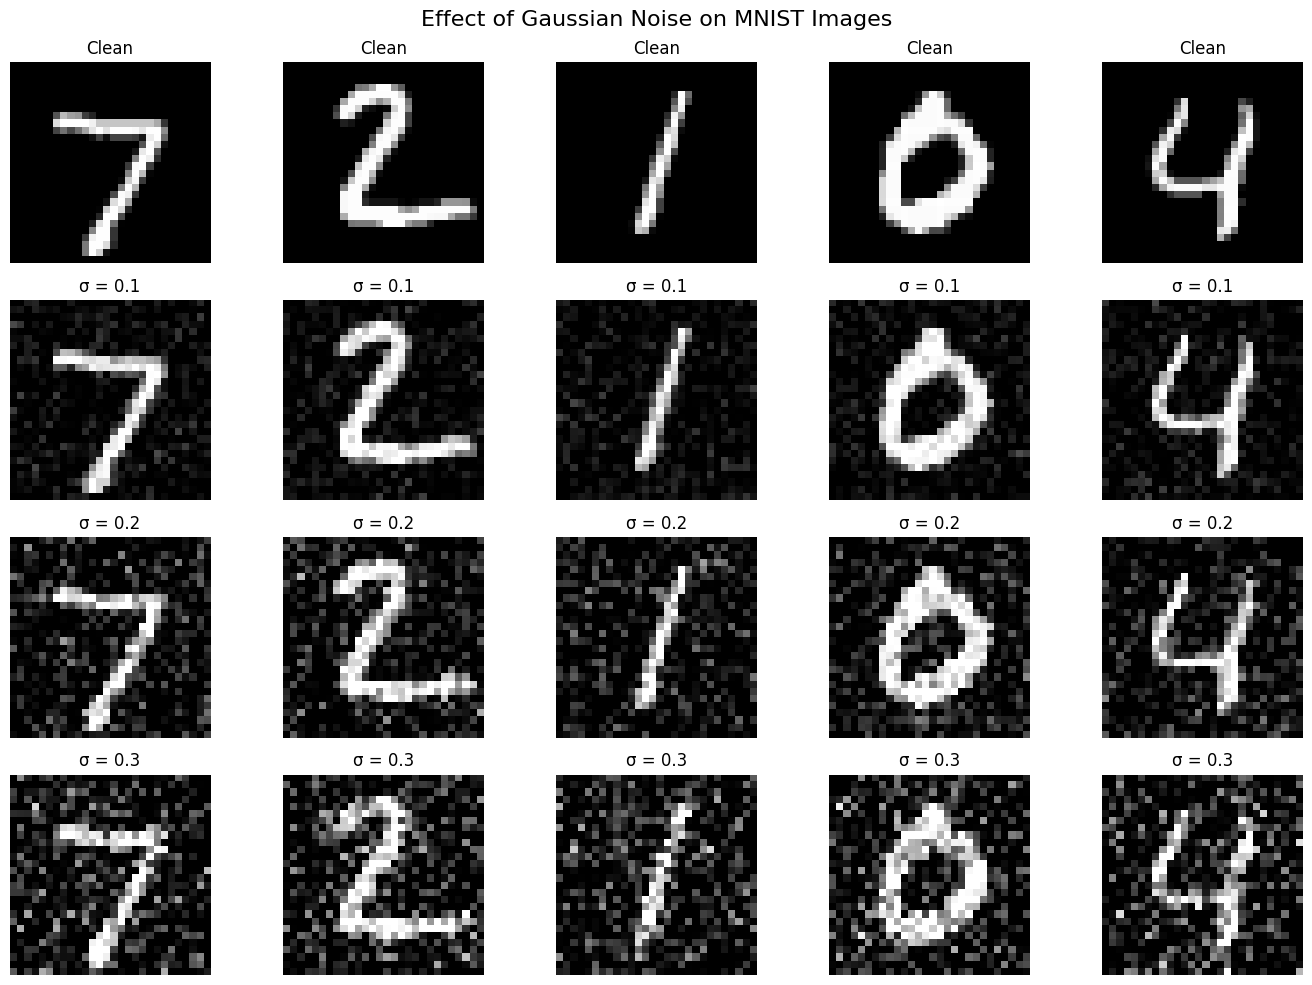

GAUSSIAN NOISE VISUALIZATION
Observation:
• σ = 0.1 introduces relatively mild corruption.
• σ = 0.2 introduces stronger corruption.
• σ = 0.3 produces the strongest corruption.

The clean images will remain the training targets.


In [20]:
# ============================================================
# CELL 20: VISUALIZE GAUSSIAN NOISE
# ============================================================

# Generate noisy versions using the three required noise levels
x_train_noisy_01 = add_gaussian_noise(x_train_cnn, sigma=0.1)
x_train_noisy_02 = add_gaussian_noise(x_train_cnn, sigma=0.2)
x_train_noisy_03 = add_gaussian_noise(x_train_cnn, sigma=0.3)

# Use the first test images for visualization
sample_images = x_test_cnn[:5]

sample_noisy_01 = add_gaussian_noise(sample_images, sigma=0.1)
sample_noisy_02 = add_gaussian_noise(sample_images, sigma=0.2)
sample_noisy_03 = add_gaussian_noise(sample_images, sigma=0.3)

fig, axes = plt.subplots(
    4,
    5,
    figsize=(14, 10)
)

for i in range(5):

    # Clean
    axes[0, i].imshow(
        sample_images[i].squeeze(),
        cmap="gray"
    )
    axes[0, i].set_title("Clean")
    axes[0, i].axis("off")

    # Sigma = 0.1
    axes[1, i].imshow(
        sample_noisy_01[i].squeeze(),
        cmap="gray"
    )
    axes[1, i].set_title("σ = 0.1")
    axes[1, i].axis("off")

    # Sigma = 0.2
    axes[2, i].imshow(
        sample_noisy_02[i].squeeze(),
        cmap="gray"
    )
    axes[2, i].set_title("σ = 0.2")
    axes[2, i].axis("off")

    # Sigma = 0.3
    axes[3, i].imshow(
        sample_noisy_03[i].squeeze(),
        cmap="gray"
    )
    axes[3, i].set_title("σ = 0.3")
    axes[3, i].axis("off")

axes[0, 0].set_ylabel("Clean", fontsize=12)
axes[1, 0].set_ylabel("σ = 0.1", fontsize=12)
axes[2, 0].set_ylabel("σ = 0.2", fontsize=12)
axes[3, 0].set_ylabel("σ = 0.3", fontsize=12)

plt.suptitle(
    "Effect of Gaussian Noise on MNIST Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("=" * 70)
print("GAUSSIAN NOISE VISUALIZATION")
print("=" * 70)

print("Observation:")
print("• σ = 0.1 introduces relatively mild corruption.")
print("• σ = 0.2 introduces stronger corruption.")
print("• σ = 0.3 produces the strongest corruption.")
print("\nThe clean images will remain the training targets.")
print("=" * 70)

In [21]:
# ============================================================
# CELL 21: BUILD DENOISING CONVOLUTIONAL AUTOENCODER
# ============================================================

print("=" * 70)
print("BUILDING DENOISING CONVOLUTIONAL AUTOENCODER")
print("=" * 70)

# Input
dcae_input = keras.Input(
    shape=(28, 28, 1),
    name="noisy_input"
)

# ============================================================
# ENCODER
# ============================================================

dcae_x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same",
    name="dcae_encoder_conv_32"
)(dcae_input)

dcae_x = layers.MaxPooling2D(
    (2, 2),
    padding="same",
    name="dcae_encoder_pool_1"
)(dcae_x)

dcae_x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same",
    name="dcae_encoder_conv_64"
)(dcae_x)

dcae_x = layers.MaxPooling2D(
    (2, 2),
    padding="same",
    name="dcae_encoder_pool_2"
)(dcae_x)

# Latent feature representation
dcae_latent = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same",
    name="dcae_latent"
)(dcae_x)

# ============================================================
# DECODER
# ============================================================

dcae_x = layers.UpSampling2D(
    (2, 2),
    name="dcae_upsampling_1"
)(dcae_latent)

dcae_x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same",
    name="dcae_decoder_conv_32"
)(dcae_x)

dcae_x = layers.UpSampling2D(
    (2, 2),
    name="dcae_upsampling_2"
)(dcae_x)

# Clean image reconstruction
dcae_output = layers.Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same",
    name="dcae_output"
)(dcae_x)

# Create model
denoising_autoencoder = keras.Model(
    dcae_input,
    dcae_output,
    name="Denoising_Convolutional_Autoencoder"
)

# Compile
denoising_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

denoising_autoencoder.summary()

BUILDING DENOISING CONVOLUTIONAL AUTOENCODER


Model: "Denoising_Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dcae_encoder_conv_32 (Conv2D)   │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dcae_encoder_pool_1             │ (None, 14, 14, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dcae_encoder_conv_64 (Conv2D)   │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dcae_encoder_pool_2             │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dcae_latent (Conv2D)            │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dcae_upsampling_1               │ (None, 14, 14, 64)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dcae_decoder_conv_32 (Conv2D)   │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dcae_upsampling_2               │ (None, 28, 28, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dcae_output (Conv2D)            │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# ============================================================
# CELL 21 (RE-RUN): BUILD DENOISING CONVOLUTIONAL AUTOENCODER
# ============================================================

from tensorflow.keras import layers, Model

# Input
denoise_input = layers.Input(shape=(28, 28, 1), name="denoise_input")

# Encoder
x = layers.Conv2D(
    32, (3, 3),
    activation="relu",
    padding="same"
)(denoise_input)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

x = layers.Conv2D(
    64, (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

# Latent representation
x = layers.Conv2D(
    64, (3, 3),
    activation="relu",
    padding="same",
    name="denoising_latent"
)(x)

# Decoder
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(
    32, (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D((2, 2))(x)

denoise_output = layers.Conv2D(
    1, (3, 3),
    activation="sigmoid",
    padding="same"
)(x)

# Create model
denoising_ae = Model(
    denoise_input,
    denoise_output,
    name="Denoising_Autoencoder"
)

# Compile
denoising_ae.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

# Display architecture
denoising_ae.summary()

print("\nDenoising Autoencoder created successfully.")
print("Input shape :", denoising_ae.input_shape)
print("Output shape:", denoising_ae.output_shape)
print("Parameters  :", denoising_ae.count_params())

Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ denoise_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ denoising_latent (Conv2D)       │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)


Denoising Autoencoder created successfully.
Input shape : (None, 28, 28, 1)
Output shape: (None, 28, 28, 1)
Parameters  : 74497


In [26]:
# ============================================================
# CELL 22: TRAIN DENOISING AUTOENCODER
# ============================================================

print("=" * 70)
print("TRAINING DENOISING CONVOLUTIONAL AUTOENCODER")
print("=" * 70)

# Use sigma = 0.2 as the training corruption level
dcae_train_input = add_gaussian_noise(
    x_train_cnn,
    sigma=0.2
)

dcae_validation_input = add_gaussian_noise(
    x_test_cnn,
    sigma=0.2
)

print("\nTraining configuration:")
print("Input  : Noisy MNIST images (σ = 0.2)")
print("Target : Clean MNIST images")
print("Epochs : 20")
print("Batch  : 128")

start_time_dcae = time.time()

dcae_history = denoising_autoencoder.fit(
    dcae_train_input,
    x_train_cnn,
    epochs=20,
    batch_size=128,
    validation_data=(
        dcae_validation_input,
        x_test_cnn
    ),
    shuffle=True,
    verbose=1
)

dcae_training_time = time.time() - start_time_dcae

print("\n" + "=" * 70)
print("DENOISING TRAINING COMPLETED")
print("=" * 70)

print(f"Training time         : {dcae_training_time:.2f} seconds")
print(f"Final training loss   : {dcae_history.history['loss'][-1]:.6f}")
print(f"Final validation loss : {dcae_history.history['val_loss'][-1]:.6f}")

print("=" * 70)

TRAINING DENOISING CONVOLUTIONAL AUTOENCODER

Training configuration:
Input  : Noisy MNIST images (σ = 0.2)
Target : Clean MNIST images
Epochs : 20
Batch  : 128
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 381ms/step - loss: 0.0750 - val_loss: 0.0735
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 380ms/step - loss: 0.0747 - val_loss: 0.0733
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 394ms/step - loss: 0.0745 - val_loss: 0.0731
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 400ms/step - loss: 0.0743 - val_loss: 0.0730
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 398ms/step - loss: 0.0741 - val_loss: 0.0730
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 402ms/step - loss: 0.0739 - val_loss: 0.0728
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - loss: 0.0738 - val_loss: 0.0727
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 379ms/step - loss: 0.0736 - val_loss: 0.0725
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - loss: 0.0735 - val_loss: 0.0724
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - 

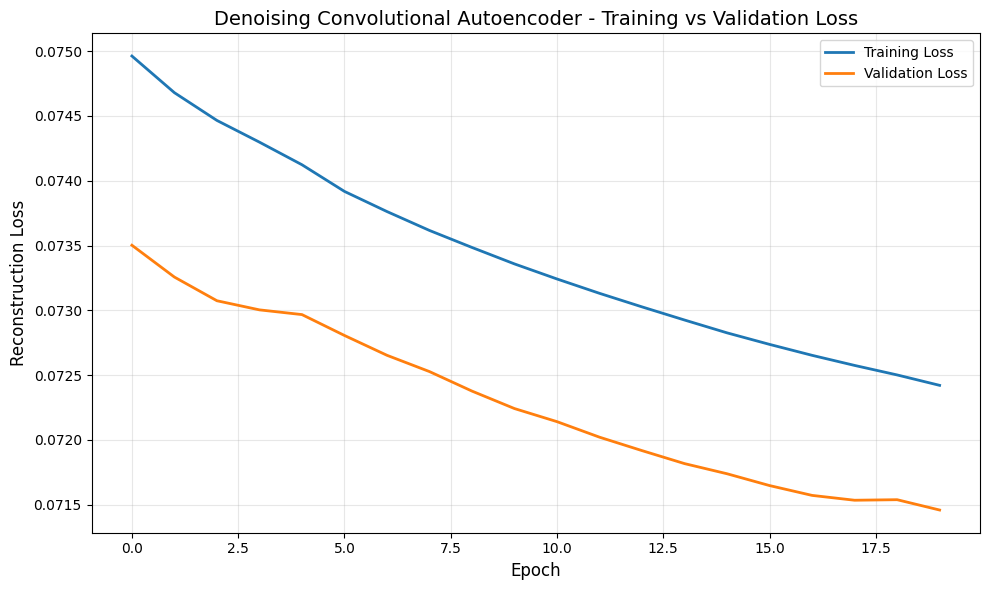

DENOISING MODEL TRAINING ANALYSIS
Initial Training Loss   : 0.074962
Final Training Loss     : 0.072421
Initial Validation Loss : 0.073502
Final Validation Loss   : 0.071459

The model learns to map corrupted images
to their corresponding clean images.


In [28]:
# ============================================================
# CELL 23: DENOISING AUTOENCODER LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    dcae_history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    dcae_history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Reconstruction Loss", fontsize=12)

plt.title(
    "Denoising Convolutional Autoencoder - Training vs Validation Loss",
    fontsize=14
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 70)
print("DENOISING MODEL TRAINING ANALYSIS")
print("=" * 70)

print(
    f"Initial Training Loss   : "
    f"{dcae_history.history['loss'][0]:.6f}"
)

print(
    f"Final Training Loss     : "
    f"{dcae_history.history['loss'][-1]:.6f}"
)

print(
    f"Initial Validation Loss : "
    f"{dcae_history.history['val_loss'][0]:.6f}"
)

print(
    f"Final Validation Loss   : "
    f"{dcae_history.history['val_loss'][-1]:.6f}"
)

print("\nThe model learns to map corrupted images")
print("to their corresponding clean images.")

print("=" * 70)

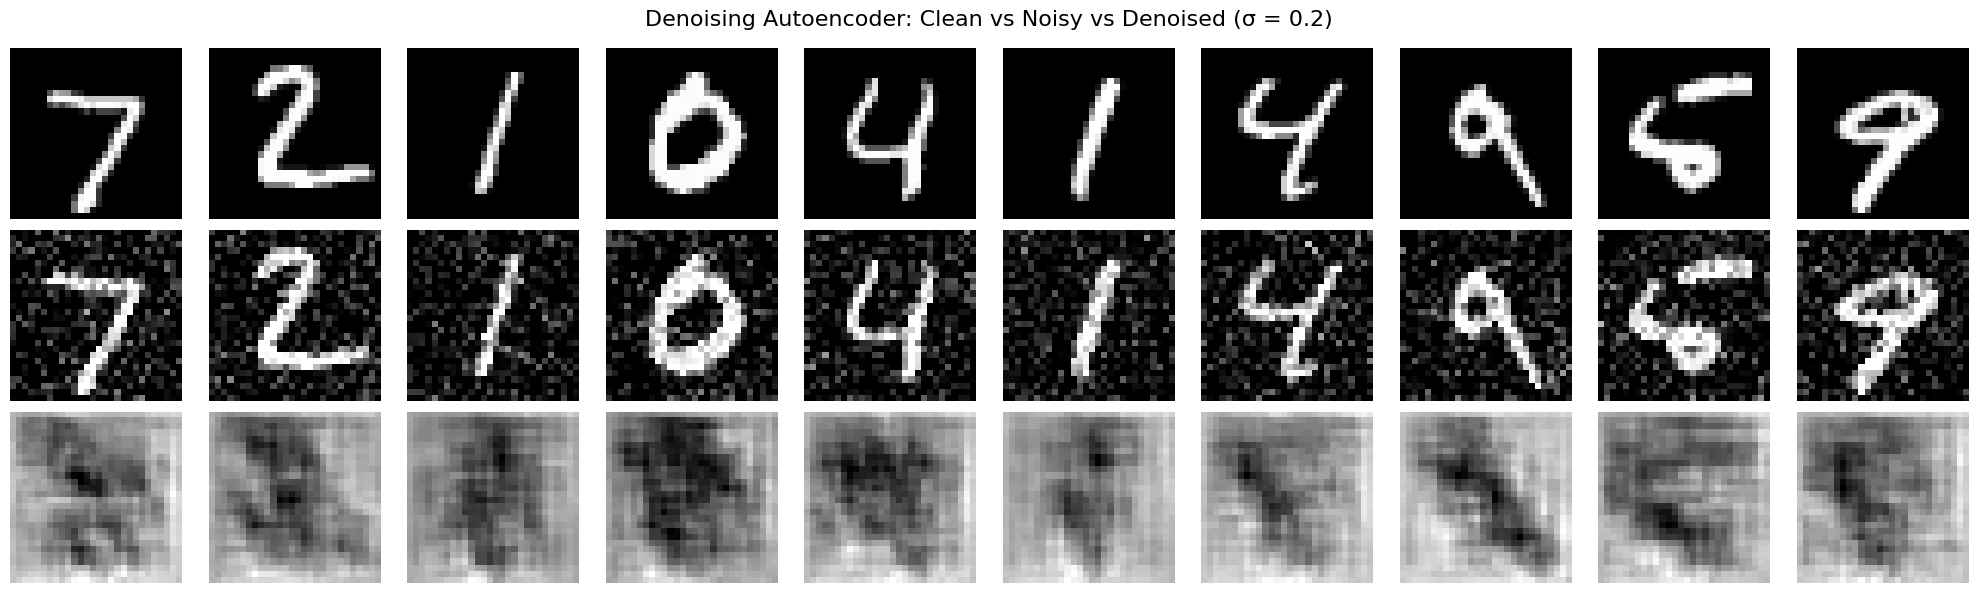

Denoising visualization completed.
Noise Level (σ): 0.2
Images displayed: 10


In [29]:
# ============================================================
# CELL 24: DENOISING OUTPUT VISUALIZATION
# Clean vs Noisy vs Denoised
# ============================================================

# Generate noisy test images at sigma = 0.2
x_test_noisy_02 = add_gaussian_noise(x_test_cnn, sigma=0.2)

# Denoise
x_test_denoised = denoising_ae.predict(
    x_test_noisy_02,
    verbose=0
)

# Plot 10 samples
num_samples = 10

fig, axes = plt.subplots(3, num_samples, figsize=(20, 6))

for i in range(num_samples):

    # Clean
    axes[0, i].imshow(x_test_cnn[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # Noisy
    axes[1, i].imshow(x_test_noisy_02[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

    # Denoised
    axes[2, i].imshow(x_test_denoised[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel("Clean", fontsize=12)
axes[1, 0].set_ylabel("Noisy", fontsize=12)
axes[2, 0].set_ylabel("Denoised", fontsize=12)

plt.suptitle(
    "Denoising Autoencoder: Clean vs Noisy vs Denoised (σ = 0.2)",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("Denoising visualization completed.")
print("Noise Level (σ): 0.2")
print("Images displayed:", num_samples)

In [31]:
# ============================================================
# CELL 25: DENOISING PERFORMANCE AT DIFFERENT NOISE LEVELS
# ============================================================

# ============================================================
# FIX: IMPORT SSIM FUNCTION
# ============================================================

from skimage.metrics import structural_similarity

print("structural_similarity imported successfully.")

noise_levels = [0.1, 0.2, 0.3]

denoising_results = []

for sigma in noise_levels:

    # Add Gaussian noise
    noisy_images = add_gaussian_noise(
        x_test_cnn,
        sigma=sigma
    )

    # Denoise
    denoised_images = denoising_ae.predict(
        noisy_images,
        verbose=0
    )

    # Remove channel dimension
    clean_images = x_test_cnn.squeeze()
    denoised_images_2d = denoised_images.squeeze()

    # MSE
    mse = mean_squared_error(
        clean_images.flatten(),
        denoised_images_2d.flatten()
    )

    # MAE
    mae = mean_absolute_error(
        clean_images.flatten(),
        denoised_images_2d.flatten()
    )

    # SSIM
    ssim_scores = []

    for i in range(len(clean_images)):
        score = structural_similarity(
            clean_images[i],
            denoised_images_2d[i],
            data_range=1.0
        )
        ssim_scores.append(score)

    ssim = np.mean(ssim_scores)

    denoising_results.append([
        sigma,
        mse,
        mae,
        ssim
    ])

# Create results table
denoising_df = pd.DataFrame(
    denoising_results,
    columns=["Gaussian Noise σ", "MSE", "MAE", "SSIM"]
)

print("DENOISING AUTOENCODER PERFORMANCE")
print("=" * 60)

display(
    denoising_df.style.format({
        "Gaussian Noise σ": "{:.1f}",
        "MSE": "{:.6f}",
        "MAE": "{:.6f}",
        "SSIM": "{:.6f}"
    })
)

structural_similarity imported successfully.
DENOISING AUTOENCODER PERFORMANCE


,Gaussian Noise σ,MSE,MAE,SSIM
0,0.1,0.228792,0.470260,-0.002904
1,0.2,0.227955,0.469419,-0.001729
2,0.3,0.227147,0.468600,-0.000658


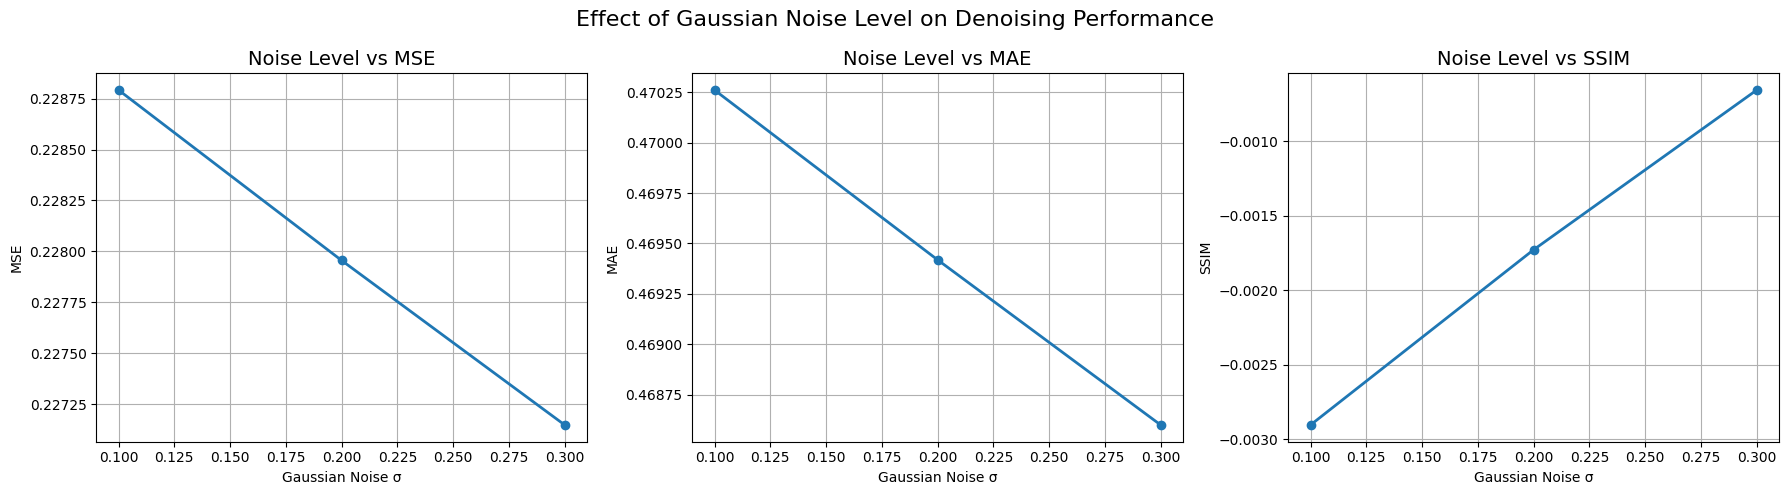

Noise-level performance plots generated successfully.


In [32]:
# ============================================================
# CELL 26: NOISE LEVEL vs MSE, MAE AND SSIM
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------- MSE ----------------
axes[0].plot(
    denoising_df["Gaussian Noise σ"],
    denoising_df["MSE"],
    marker="o",
    linewidth=2
)

axes[0].set_title("Noise Level vs MSE", fontsize=14)
axes[0].set_xlabel("Gaussian Noise σ")
axes[0].set_ylabel("MSE")
axes[0].grid(True)

# ---------------- MAE ----------------
axes[1].plot(
    denoising_df["Gaussian Noise σ"],
    denoising_df["MAE"],
    marker="o",
    linewidth=2
)

axes[1].set_title("Noise Level vs MAE", fontsize=14)
axes[1].set_xlabel("Gaussian Noise σ")
axes[1].set_ylabel("MAE")
axes[1].grid(True)

# ---------------- SSIM ----------------
axes[2].plot(
    denoising_df["Gaussian Noise σ"],
    denoising_df["SSIM"],
    marker="o",
    linewidth=2
)

axes[2].set_title("Noise Level vs SSIM", fontsize=14)
axes[2].set_xlabel("Gaussian Noise σ")
axes[2].set_ylabel("SSIM")
axes[2].grid(True)

plt.suptitle(
    "Effect of Gaussian Noise Level on Denoising Performance",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("Noise-level performance plots generated successfully.")

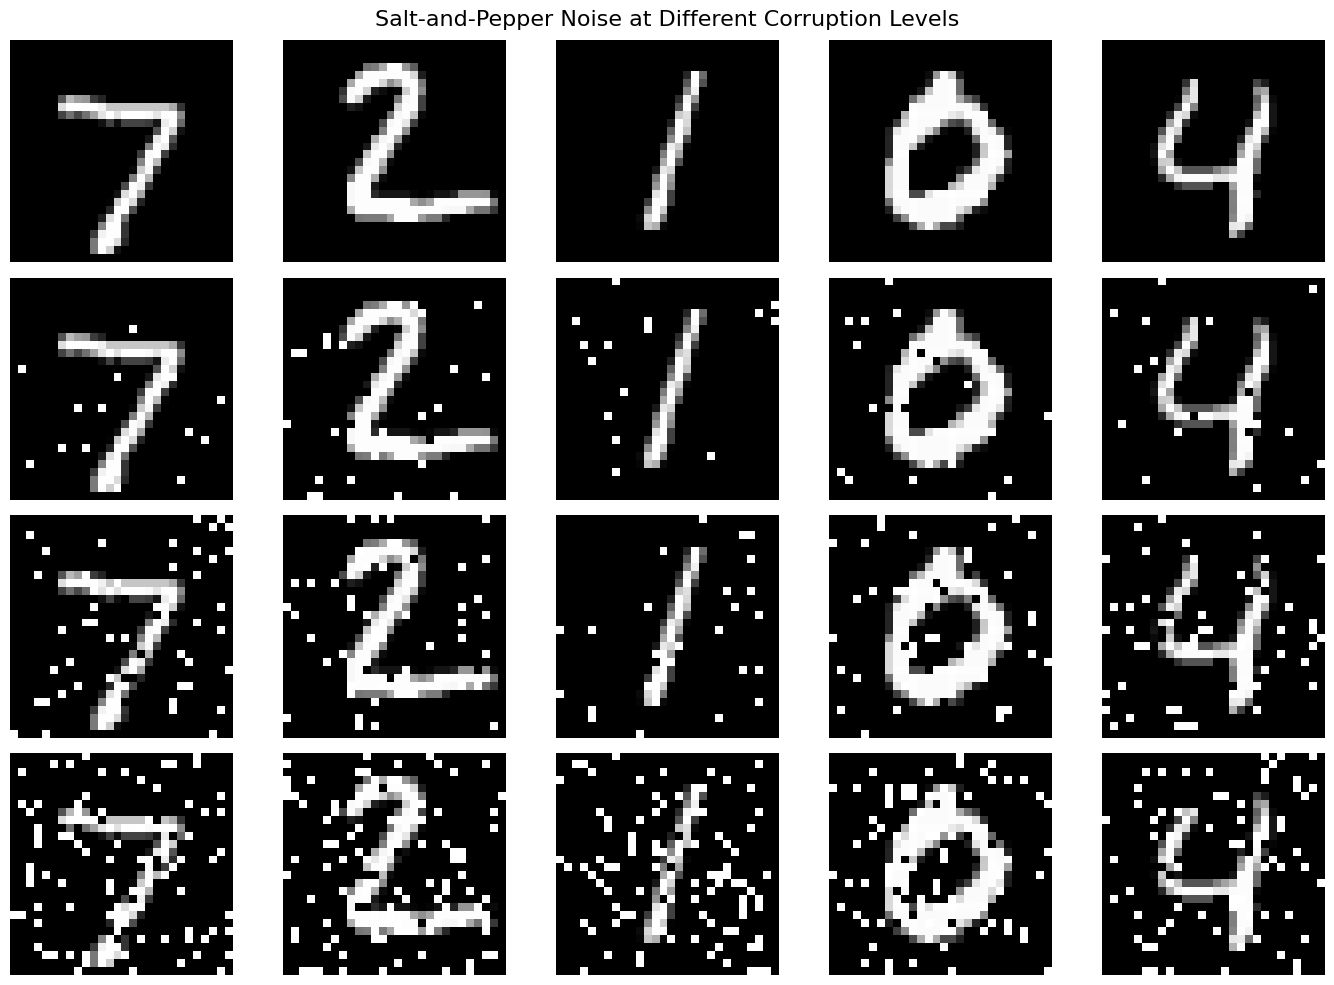

Salt-and-pepper noise visualization completed.
Noise levels tested: [0.05, 0.1, 0.2]


In [33]:
# ============================================================
# CELL 27: SALT-AND-PEPPER NOISE
# ============================================================

def add_salt_pepper_noise(images, probability=0.10):
    """
    Add salt-and-pepper noise to images.

    probability:
        Total probability of corruption.
        Half becomes black (pepper)
        Half becomes white (salt)
    """

    noisy = images.copy()

    # Random values for deciding which pixels are corrupted
    random_values = np.random.random(images.shape)

    # Salt: pixels become 1
    salt_mask = random_values < (probability / 2)

    # Pepper: pixels become 0
    pepper_mask = (
        (random_values >= probability / 2) &
        (random_values < probability)
    )

    noisy[salt_mask] = 1.0
    noisy[pepper_mask] = 0.0

    return noisy


# Generate different salt-and-pepper noise levels
sp_levels = [0.05, 0.10, 0.20]

sp_noisy_samples = {}

for p in sp_levels:
    sp_noisy_samples[p] = add_salt_pepper_noise(
        x_test_cnn,
        probability=p
    )


# ============================================================
# VISUALIZATION
# ============================================================

num_samples = 5

fig, axes = plt.subplots(
    4,
    num_samples,
    figsize=(14, 10)
)

# Clean images
for i in range(num_samples):
    axes[0, i].imshow(
        x_test_cnn[i].squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")

axes[0, 0].set_ylabel(
    "Clean",
    fontsize=12
)

# Noisy images
for row, p in enumerate(sp_levels, start=1):

    for i in range(num_samples):
        axes[row, i].imshow(
            sp_noisy_samples[p][i].squeeze(),
            cmap="gray"
        )
        axes[row, i].axis("off")

    axes[row, 0].set_ylabel(
        f"S&P p={p}",
        fontsize=12
    )


plt.suptitle(
    "Salt-and-Pepper Noise at Different Corruption Levels",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("Salt-and-pepper noise visualization completed.")
print("Noise levels tested:", sp_levels)

In [34]:
# ============================================================
# CELL 28: TRAIN DENOISING AE WITH SALT-AND-PEPPER NOISE
# ============================================================

# Generate noisy training and validation inputs
x_train_sp = add_salt_pepper_noise(
    x_train_cnn,
    probability=0.10
)

x_test_sp = add_salt_pepper_noise(
    x_test_cnn,
    probability=0.10
)

print("Training data shape :", x_train_sp.shape)
print("Validation data shape:", x_test_sp.shape)
print("Noise type          : Salt-and-Pepper")
print("Noise probability   : 0.10")


# Train the denoising autoencoder
start_time_sp = time.time()

history_sp = denoising_ae.fit(
    x_train_sp,
    x_train_cnn,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_sp, x_test_cnn),
    verbose=1
)

training_time_sp = time.time() - start_time_sp

print("\nSalt-and-Pepper Denoising Training Completed!")
print(f"Training Time: {training_time_sp:.2f} seconds")

Training data shape : (10000, 28, 28, 1)
Validation data shape: (2000, 28, 28, 1)
Noise type          : Salt-and-Pepper
Noise probability   : 0.10
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 377ms/step - loss: 0.2454 - val_loss: 0.1176
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 374ms/step - loss: 0.1030 - val_loss: 0.0937
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 373ms/step - loss: 0.0912 - val_loss: 0.0875
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 386ms/step - loss: 0.0871 - val_loss: 0.0856
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 377ms/step - loss: 0.0845 - val_loss: 0.0826
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 372ms/step - loss: 0.0827 - val_loss: 0.0808
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 373ms/step - loss: 0.0815 - val_loss: 0.0804
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - loss: 0.0804 - val_loss: 0.0789
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 373ms/step - loss: 0.0795 - val_loss: 0.0782
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 383ms/step - loss: 0.0788 -

SALT-AND-PEPPER DENOISING PERFORMANCE
Noise Probability : 0.10
MSE               : 0.004813
MAE               : 0.020720
SSIM              : 0.946327


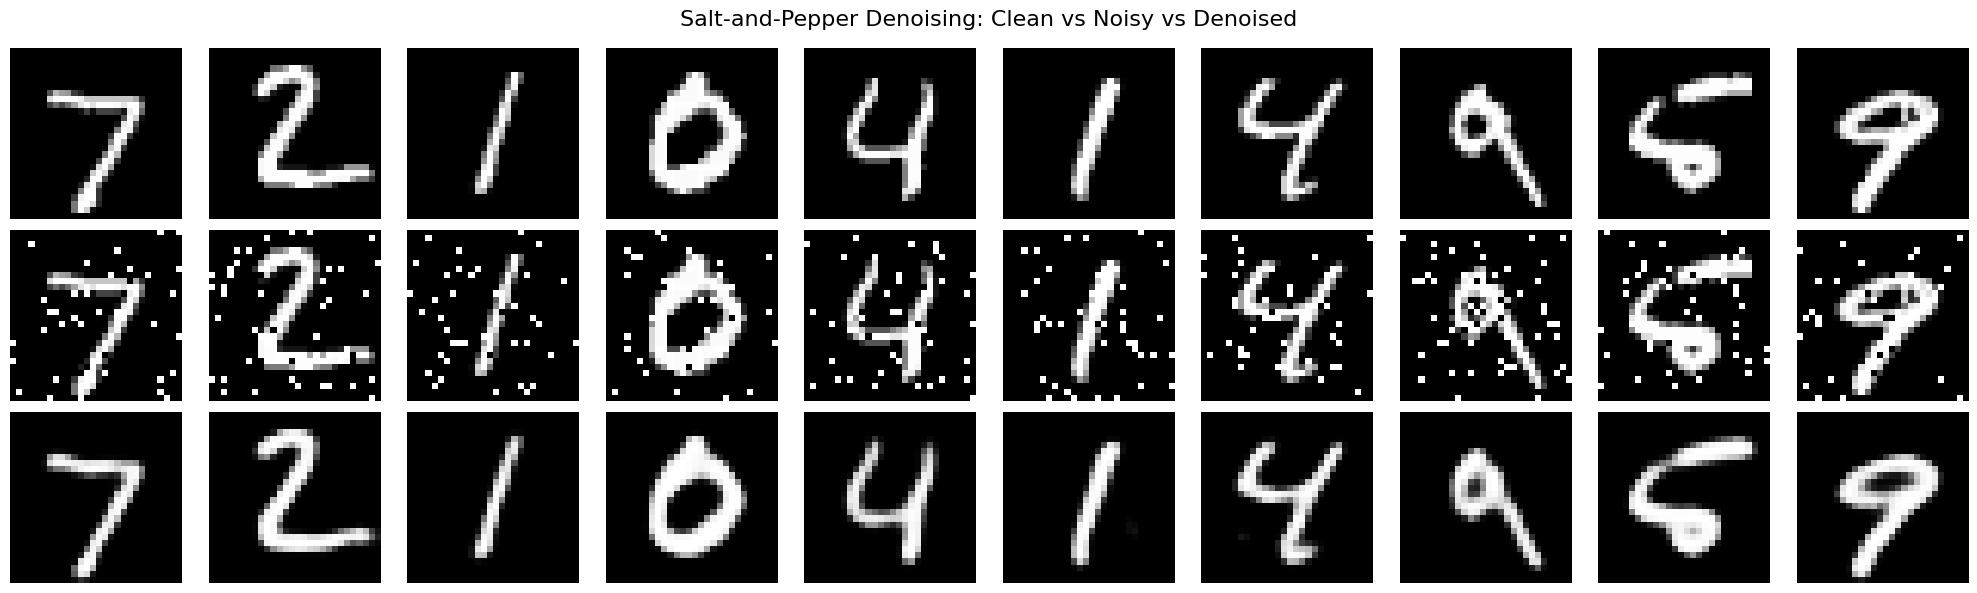

In [35]:
# ============================================================
# CELL 29: SALT-AND-PEPPER DENOISING RESULTS
# ============================================================

# Reconstruct noisy test images
x_test_sp_denoised = denoising_ae.predict(
    x_test_sp,
    verbose=0
)

# Remove channel dimension
clean_sp = x_test_cnn.squeeze()
noisy_sp = x_test_sp.squeeze()
denoised_sp = x_test_sp_denoised.squeeze()

# Calculate metrics
sp_mse = mean_squared_error(
    clean_sp.flatten(),
    denoised_sp.flatten()
)

sp_mae = mean_absolute_error(
    clean_sp.flatten(),
    denoised_sp.flatten()
)

sp_ssim_scores = []

for i in range(len(clean_sp)):
    score = structural_similarity(
        clean_sp[i],
        denoised_sp[i],
        data_range=1.0
    )
    sp_ssim_scores.append(score)

sp_ssim = np.mean(sp_ssim_scores)

print("=" * 60)
print("SALT-AND-PEPPER DENOISING PERFORMANCE")
print("=" * 60)

print(f"Noise Probability : 0.10")
print(f"MSE               : {sp_mse:.6f}")
print(f"MAE               : {sp_mae:.6f}")
print(f"SSIM              : {sp_ssim:.6f}")


# ============================================================
# VISUAL COMPARISON
# ============================================================

num_samples = 10

fig, axes = plt.subplots(
    3,
    num_samples,
    figsize=(20, 6)
)

for i in range(num_samples):

    # Clean
    axes[0, i].imshow(
        clean_sp[i],
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Noisy
    axes[1, i].imshow(
        noisy_sp[i],
        cmap="gray"
    )
    axes[1, i].axis("off")

    # Denoised
    axes[2, i].imshow(
        denoised_sp[i],
        cmap="gray"
    )
    axes[2, i].axis("off")


axes[0, 0].set_ylabel(
    "Clean",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "Noisy",
    fontsize=12
)

axes[2, 0].set_ylabel(
    "Denoised",
    fontsize=12
)

plt.suptitle(
    "Salt-and-Pepper Denoising: Clean vs Noisy vs Denoised",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# CELL 30: VAE - SAMPLING LAYER AND ENCODER
# ============================================================

from tensorflow.keras import backend as K

# Latent dimension required by the assignment
latent_dim = 2


# ------------------------------------------------------------
# Sampling Layer
# z = mu + sigma * epsilon
# ------------------------------------------------------------

class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(
            shape=(batch, dim)
        )

        return z_mean + tf.exp(
            0.5 * z_log_var
        ) * epsilon


# ------------------------------------------------------------
# VAE Encoder
# ------------------------------------------------------------

vae_encoder_inputs = layers.Input(
    shape=(28, 28, 1),
    name="vae_encoder_input"
)

x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(vae_encoder_inputs)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

x = layers.Flatten()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

# Mean of latent distribution
z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)

# Log variance of latent distribution
z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)

# Reparameterization trick
z = Sampling()(
    [z_mean, z_log_var]
)

# Create encoder
vae_encoder = Model(
    vae_encoder_inputs,
    [z_mean, z_log_var, z],
    name="VAE_Encoder"
)

print("=" * 60)
print("VAE ENCODER CREATED")
print("=" * 60)

vae_encoder.summary()

print("\nLatent Dimension:", latent_dim)
print("Encoder Output:")
print("  z_mean   :", z_mean.shape)
print("  z_log_var:", z_log_var.shape)
print("  z        :", z.shape)

VAE ENCODER CREATED


Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │        320 │ vae_encoder_inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 64)  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)


Latent Dimension: 2
Encoder Output:
  z_mean   : (None, 2)
  z_log_var: (None, 2)
  z        : (None, 2)


In [37]:
# ============================================================
# CELL 31: VAE DECODER
# ============================================================

latent_inputs = layers.Input(
    shape=(latent_dim,),
    name="vae_decoder_input"
)

x = layers.Dense(
    7 * 7 * 64,
    activation="relu"
)(latent_inputs)

x = layers.Reshape((7, 7, 64))(x)

x = layers.Conv2DTranspose(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2DTranspose(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D((2, 2))(x)

vae_decoder_outputs = layers.Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same",
    name="vae_output"
)(x)

vae_decoder = Model(
    latent_inputs,
    vae_decoder_outputs,
    name="VAE_Decoder"
)

print("=" * 60)
print("VAE DECODER CREATED")
print("=" * 60)

vae_decoder.summary()

print("\nDecoder input :", vae_decoder.input_shape)
print("Decoder output:", vae_decoder.output_shape)

VAE DECODER CREATED


Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae_decoder_input (InputLayer)  │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_output (Conv2D)             │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)


Decoder input : (None, 2)
Decoder output: (None, 28, 28, 1)


In [38]:
# ============================================================
# CELL 32: COMPLETE VAE WITH RECONSTRUCTION + KL LOSS
# ============================================================

class VAE(Model):

    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

        self.total_loss_tracker = tf.keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = tf.keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(
                data,
                training=True
            )

            reconstruction = self.decoder(
                z,
                training=True
            )

            # Binary cross entropy per pixel
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = (
                reconstruction_loss
                + self.beta * kl_loss
            )

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(
            data,
            training=False
        )

        reconstruction = self.decoder(
            z,
            training=False
        )

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                ),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = (
            reconstruction_loss
            + self.beta * kl_loss
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }


# Create VAE
vae = VAE(
    vae_encoder,
    vae_decoder,
    beta=1.0,
    name="Variational_Autoencoder"
)

vae.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
)

print("=" * 60)
print("COMPLETE VAE CREATED")
print("=" * 60)

print("Latent dimension:", latent_dim)
print("Beta:", vae.beta)
print("Optimizer: Adam")
print("Learning rate: 0.001")

COMPLETE VAE CREATED
Latent dimension: 2
Beta: 1.0
Optimizer: Adam
Learning rate: 0.001


In [39]:
# ============================================================
# CELL 32: COMPLETE VAE WITH RECONSTRUCTION + KL LOSS
# ============================================================

class VAE(Model):

    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

        self.total_loss_tracker = tf.keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = tf.keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(
                data,
                training=True
            )

            reconstruction = self.decoder(
                z,
                training=True
            )

            # Binary cross entropy per pixel
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = (
                reconstruction_loss
                + self.beta * kl_loss
            )

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(
            data,
            training=False
        )

        reconstruction = self.decoder(
            z,
            training=False
        )

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                ),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = (
            reconstruction_loss
            + self.beta * kl_loss
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }


# Create VAE
vae = VAE(
    vae_encoder,
    vae_decoder,
    beta=1.0,
    name="Variational_Autoencoder"
)

vae.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
)

print("=" * 60)
print("COMPLETE VAE CREATED")
print("=" * 60)

print("Latent dimension:", latent_dim)
print("Beta:", vae.beta)
print("Optimizer: Adam")
print("Learning rate: 0.001")

COMPLETE VAE CREATED
Latent dimension: 2
Beta: 1.0
Optimizer: Adam
Learning rate: 0.001


In [40]:
# ============================================================
# CELL 33: TRAIN VAE
# ============================================================

start_time_vae = time.time()

history_vae = vae.fit(
    x_train_cnn,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_cnn, None),
    verbose=1
)

vae_training_time = time.time() - start_time_vae

print("\n" + "=" * 60)
print("VAE TRAINING COMPLETED")
print("=" * 60)

print(f"Training Time: {vae_training_time:.2f} seconds")
print(f"Epochs       : 20")
print(f"Batch Size   : 128")
print(f"Latent Dim   : {latent_dim}")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step - kl_loss: 1.1765 - loss: 269.8635 - reconstruction_loss: 268.6871 - val_kl_loss: 1.5483 - val_loss: 201.3696 - val_reconstruction_loss: 199.8213
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 362ms/step - kl_loss: 2.3163 - loss: 198.7084 - reconstruction_loss: 196.3921 - val_kl_loss: 2.9556 - val_loss: 183.1419 - val_reconstruction_loss: 180.1863
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - kl_loss: 4.0720 - loss: 177.4622 - reconstruction_loss: 173.3901 - val_kl_loss: 4.4112 - val_loss: 168.6407 - val_reconstruction_loss: 164.2294
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 370ms/step - kl_loss: 4.6339 - loss: 169.3378 - reconstruction_loss: 164.7039 - val_kl_loss: 4.5057 - val_loss: 167.0512 - val_reconstruction_loss: 162.5455
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 387ms/step - kl_loss: 4.8382 - loss: 165.9556 - reconstruction_loss: 161.1174 - val_kl_loss: 4.6989 - val_loss: 162.2485 - val_reconstruction_loss: 157.5496
Epoch

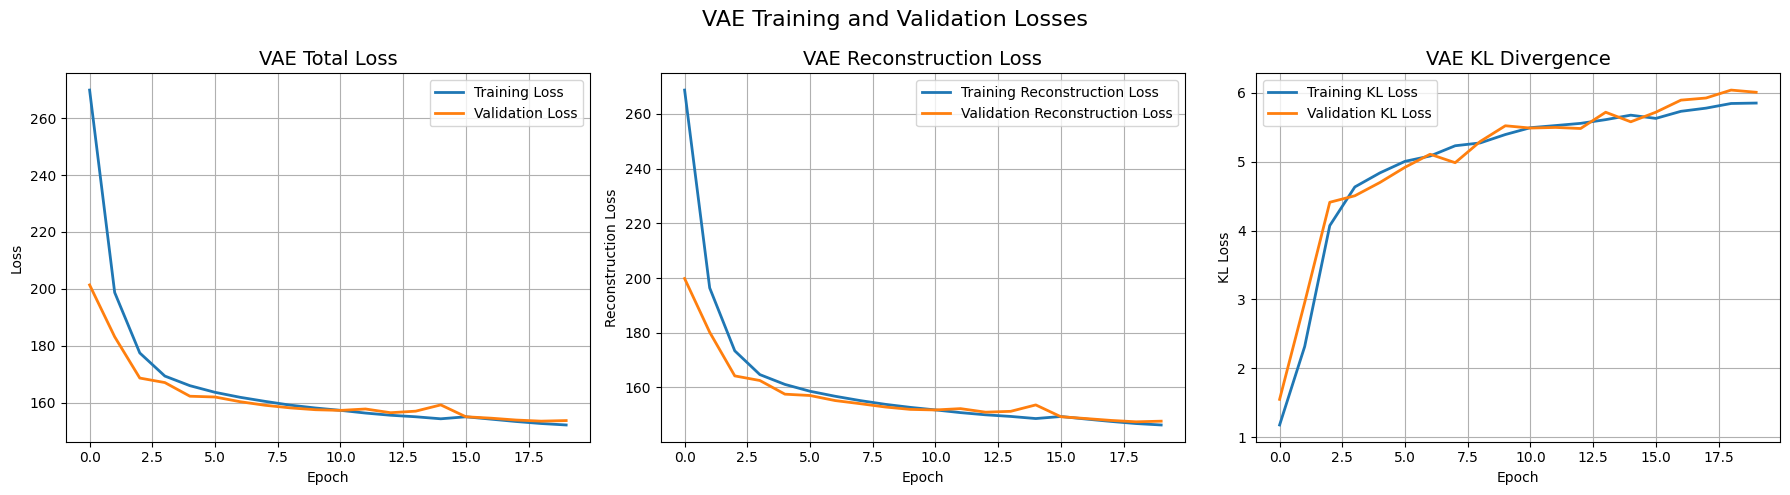

VAE loss plots generated successfully.


In [41]:
# ============================================================
# CELL 34: VAE LOSS PLOTS
# ============================================================

history_dict = history_vae.history

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

# Total loss
axes[0].plot(
    history_dict["loss"],
    label="Training Loss",
    linewidth=2
)

axes[0].plot(
    history_dict["val_loss"],
    label="Validation Loss",
    linewidth=2
)

axes[0].set_title(
    "VAE Total Loss",
    fontsize=14
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Reconstruction loss
axes[1].plot(
    history_dict["reconstruction_loss"],
    label="Training Reconstruction Loss",
    linewidth=2
)

axes[1].plot(
    history_dict["val_reconstruction_loss"],
    label="Validation Reconstruction Loss",
    linewidth=2
)

axes[1].set_title(
    "VAE Reconstruction Loss",
    fontsize=14
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Reconstruction Loss")
axes[1].legend()
axes[1].grid(True)

# KL loss
axes[2].plot(
    history_dict["kl_loss"],
    label="Training KL Loss",
    linewidth=2
)

axes[2].plot(
    history_dict["val_kl_loss"],
    label="Validation KL Loss",
    linewidth=2
)

axes[2].set_title(
    "VAE KL Divergence",
    fontsize=14
)

axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("KL Loss")
axes[2].legend()
axes[2].grid(True)

plt.suptitle(
    "VAE Training and Validation Losses",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("VAE loss plots generated successfully.")

In [42]:
# ============================================================
# CELL 35: VAE RECONSTRUCTION AND METRICS
# ============================================================

# Encode test images
z_mean_test, z_log_var_test, z_test = vae_encoder.predict(
    x_test_cnn,
    verbose=0
)

# Decode latent representations
x_test_vae_reconstructed = vae_decoder.predict(
    z_test,
    verbose=0
)

# Remove channel dimension
vae_original = x_test_cnn.squeeze()
vae_reconstructed = x_test_vae_reconstructed.squeeze()

# MSE
vae_mse = mean_squared_error(
    vae_original.flatten(),
    vae_reconstructed.flatten()
)

# MAE
vae_mae = mean_absolute_error(
    vae_original.flatten(),
    vae_reconstructed.flatten()
)

# SSIM
vae_ssim_scores = []

for i in range(len(vae_original)):

    score = structural_similarity(
        vae_original[i],
        vae_reconstructed[i],
        data_range=1.0
    )

    vae_ssim_scores.append(score)

vae_ssim = np.mean(vae_ssim_scores)

# KL divergence on test set
vae_kl = -0.5 * np.mean(
    np.sum(
        1 + z_log_var_test
        - np.square(z_mean_test)
        - np.exp(z_log_var_test),
        axis=1
    )
)

print("=" * 60)
print("VAE TEST PERFORMANCE")
print("=" * 60)

print(f"MSE               : {vae_mse:.6f}")
print(f"MAE               : {vae_mae:.6f}")
print(f"SSIM              : {vae_ssim:.6f}")
print(f"Mean KL Divergence: {vae_kl:.6f}")

VAE TEST PERFORMANCE
MSE               : 0.043134
MAE               : 0.100257
SSIM              : 0.494859
Mean KL Divergence: 6.013857


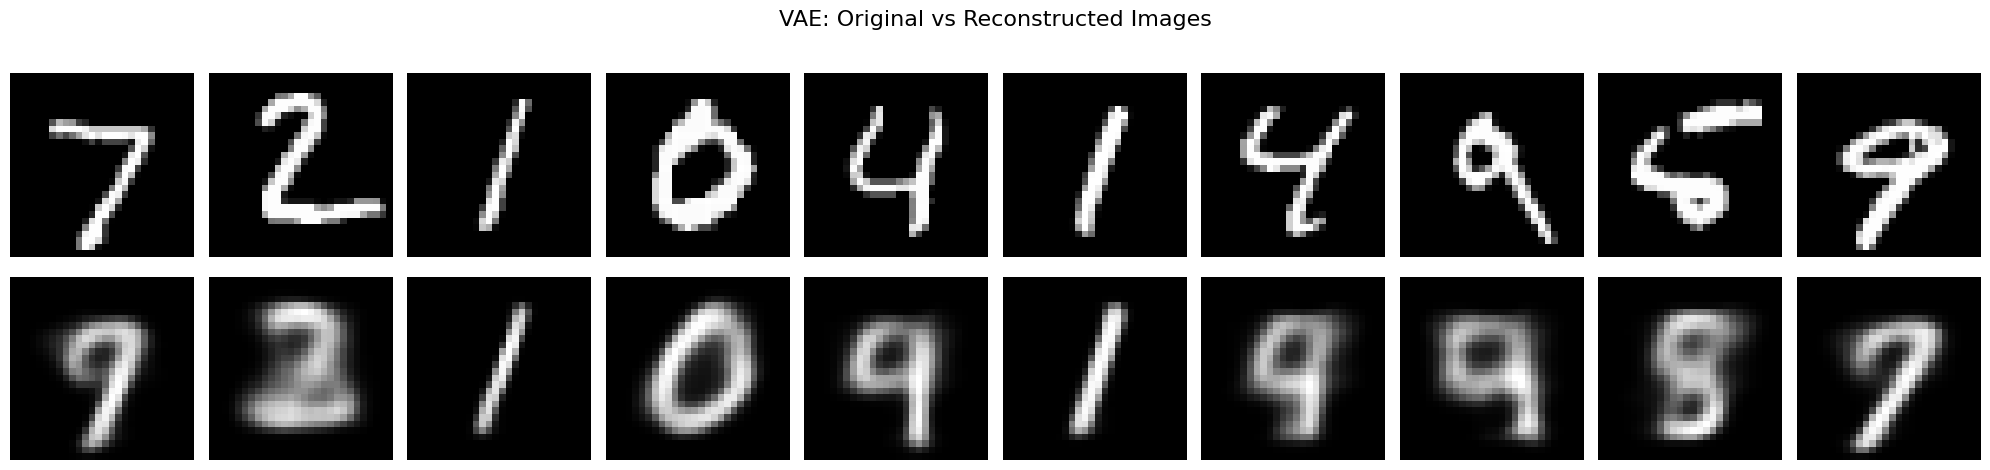

In [43]:
# ============================================================
# CELL 36: ORIGINAL VS VAE RECONSTRUCTION
# ============================================================

num_samples = 10

fig, axes = plt.subplots(
    2,
    num_samples,
    figsize=(20, 5)
)

for i in range(num_samples):

    # Original
    axes[0, i].imshow(
        vae_original[i],
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Reconstruction
    axes[1, i].imshow(
        vae_reconstructed[i],
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel(
    "Original",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "VAE",
    fontsize=12
)

plt.suptitle(
    "VAE: Original vs Reconstructed Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# FIX CELL: CREATE TEST LABEL SUBSET
# ============================================================

# Use the same 2,000 test samples used throughout the experiment
y_test_subset = y_test[:2000]

print("y_test_subset created successfully.")
print("Shape:", y_test_subset.shape)
print("First 10 labels:", y_test_subset[:10])

y_test_subset created successfully.
Shape: (2000,)
First 10 labels: [7 2 1 0 4 1 4 9 5 9]


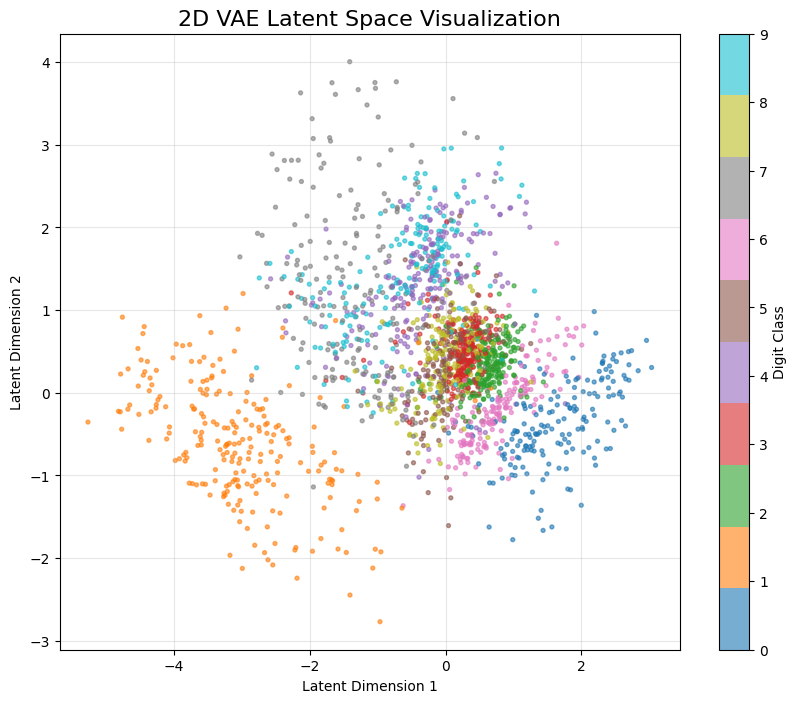

Latent representation shape: (2000, 2)
Each test image is represented by 2 latent values.


In [46]:
# ============================================================
# CELL 37: VAE 2D LATENT SPACE
# ============================================================

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test_subset,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.colorbar(
    scatter,
    ticks=range(10),
    label="Digit Class"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.title(
    "2D VAE Latent Space Visualization",
    fontsize=16
)

plt.grid(True, alpha=0.3)
plt.show()

print("Latent representation shape:", z_mean_test.shape)
print("Each test image is represented by 2 latent values.")

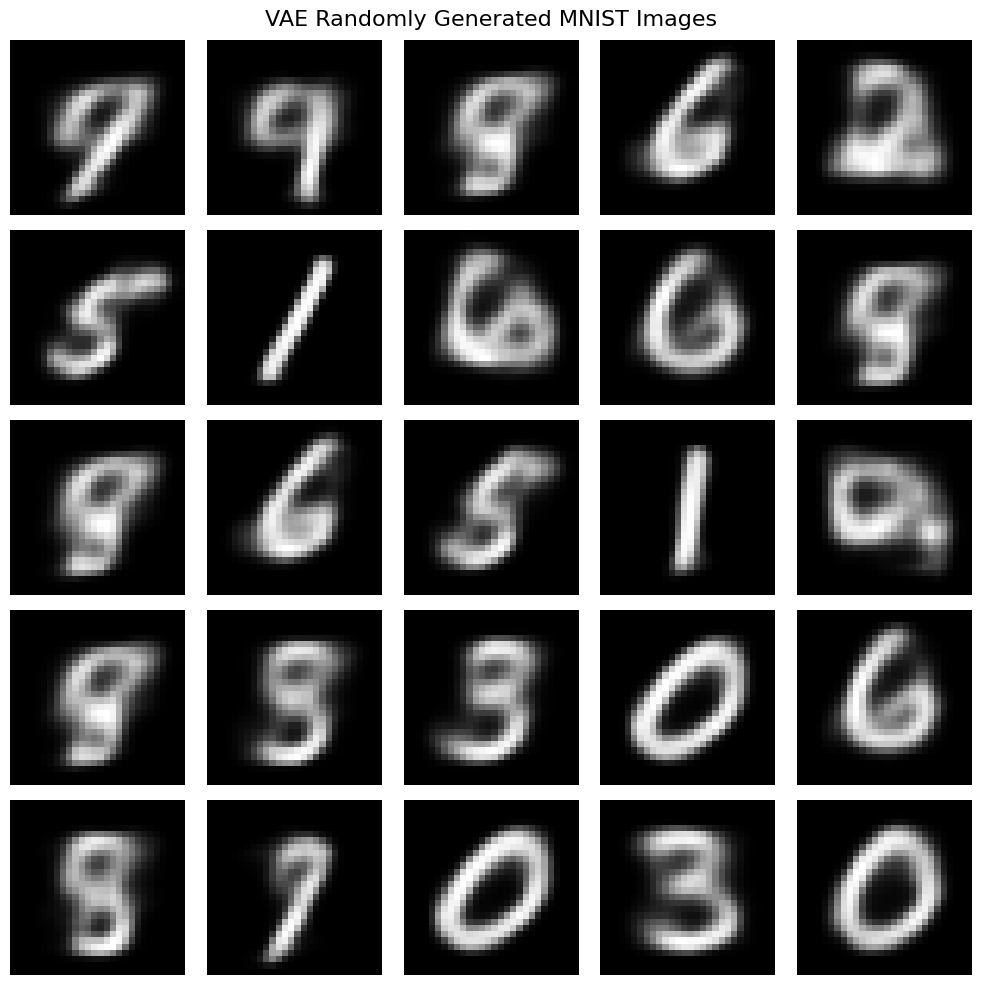

Generated images: 25
Latent distribution: N(0, I)


In [47]:
# ============================================================
# CELL 38: RANDOM IMAGE GENERATION FROM VAE
# ============================================================

num_generated = 25

# Sample random points from standard normal distribution
random_latent_vectors = np.random.normal(
    size=(num_generated, latent_dim)
).astype("float32")

# Generate images
generated_images = vae_decoder.predict(
    random_latent_vectors,
    verbose=0
)

# Plot 25 generated images
fig, axes = plt.subplots(
    5,
    5,
    figsize=(10, 10)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    ax.axis("off")

plt.suptitle(
    "VAE Randomly Generated MNIST Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("Generated images:", num_generated)
print("Latent distribution: N(0, I)")

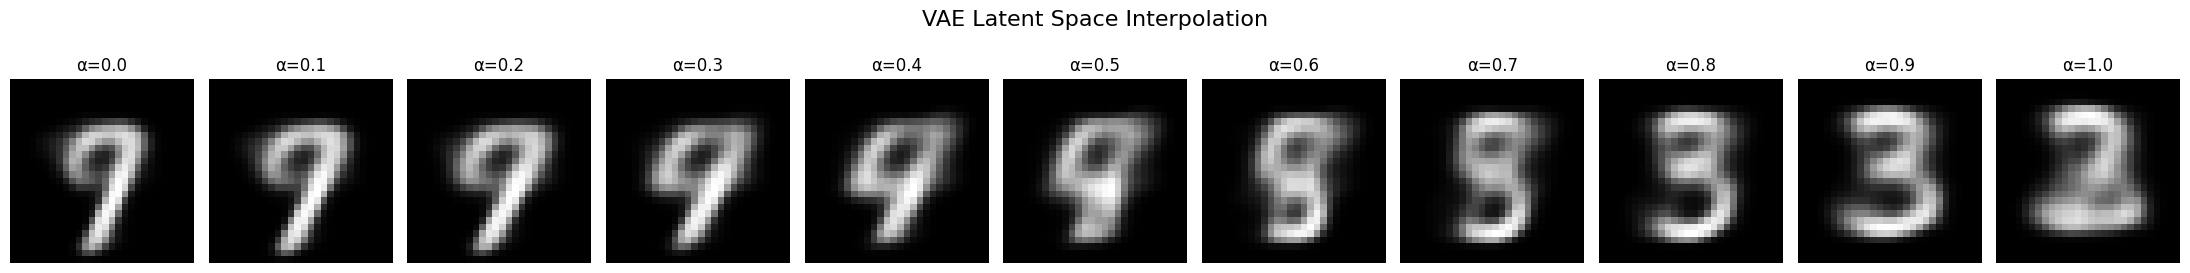

Interpolation completed.
Alpha values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [48]:
# ============================================================
# CELL 39: VAE LATENT SPACE INTERPOLATION
# ============================================================

# Select two test images
image_a = x_test_cnn[0:1]
image_b = x_test_cnn[1:2]

# Obtain their latent means
z_mean_a, _, _ = vae_encoder.predict(
    image_a,
    verbose=0
)

z_mean_b, _, _ = vae_encoder.predict(
    image_b,
    verbose=0
)

# Alpha values from 0 to 1 with step 0.1
alphas = np.arange(
    0.0,
    1.01,
    0.1
)

interpolated_latents = []

for alpha in alphas:

    z_interpolated = (
        (1 - alpha) * z_mean_a[0]
        + alpha * z_mean_b[0]
    )

    interpolated_latents.append(
        z_interpolated
    )

interpolated_latents = np.array(
    interpolated_latents,
    dtype="float32"
)

# Generate interpolated images
interpolated_images = vae_decoder.predict(
    interpolated_latents,
    verbose=0
)

# Plot
fig, axes = plt.subplots(
    1,
    len(alphas),
    figsize=(22, 3)
)

for i, ax in enumerate(axes):

    ax.imshow(
        interpolated_images[i].squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"α={alphas[i]:.1f}"
    )

    ax.axis("off")

plt.suptitle(
    "VAE Latent Space Interpolation",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("Interpolation completed.")
print("Alpha values:", alphas)

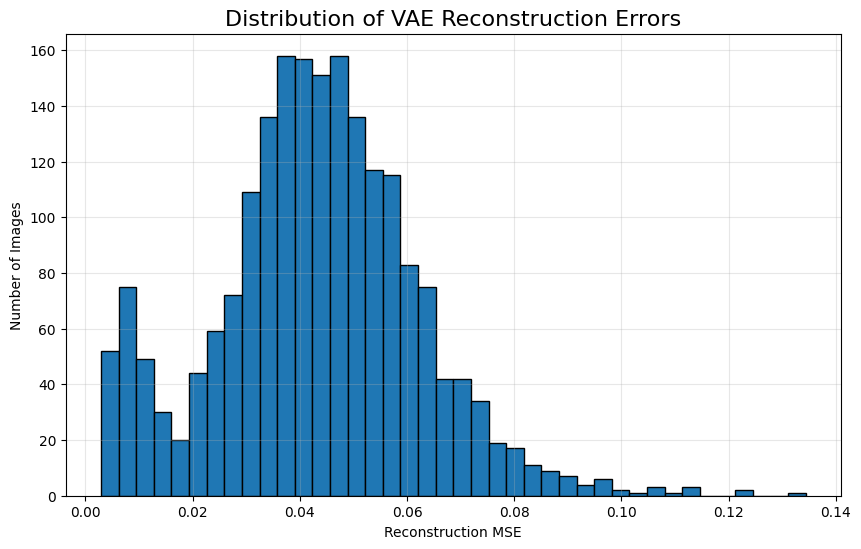

TOP 5 HIGH-ERROR VAE RECONSTRUCTIONS
Rank 1: Index = 1352, Digit = 2, MSE = 0.134376
Rank 2: Index = 998, Digit = 8, MSE = 0.124196
Rank 3: Index = 1847, Digit = 5, MSE = 0.121735
Rank 4: Index = 1325, Digit = 8, MSE = 0.113770
Rank 5: Index = 352, Digit = 5, MSE = 0.113375


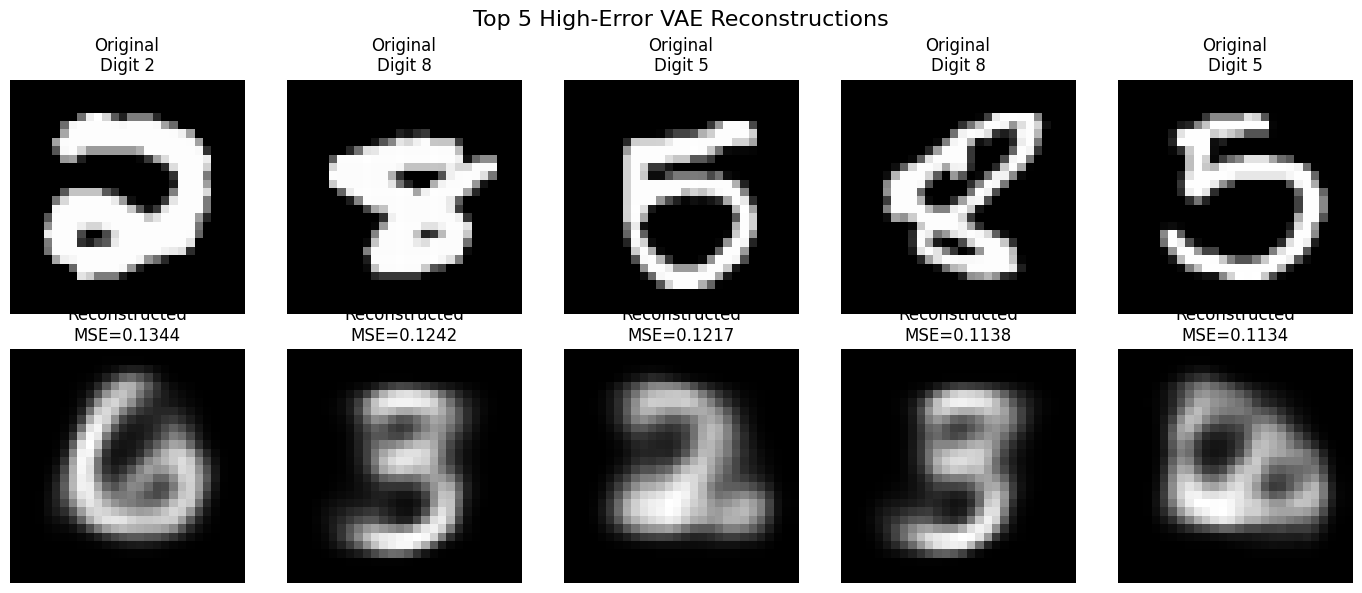

In [49]:
# ============================================================
# CELL 40: VAE RECONSTRUCTION ERROR DISTRIBUTION
# ============================================================

# Per-image MSE
vae_image_errors = np.mean(
    np.square(
        vae_original - vae_reconstructed
    ),
    axis=(1, 2)
)

# Distribution
plt.figure(figsize=(10, 6))

plt.hist(
    vae_image_errors,
    bins=40,
    edgecolor="black"
)

plt.xlabel("Reconstruction MSE")
plt.ylabel("Number of Images")

plt.title(
    "Distribution of VAE Reconstruction Errors",
    fontsize=16
)

plt.grid(True, alpha=0.3)
plt.show()


# ------------------------------------------------------------
# Top 5 High-Error Images
# ------------------------------------------------------------

top_5_indices = np.argsort(
    vae_image_errors
)[-5:][::-1]

print("=" * 60)
print("TOP 5 HIGH-ERROR VAE RECONSTRUCTIONS")
print("=" * 60)

for rank, idx in enumerate(top_5_indices, start=1):

    print(
        f"Rank {rank}: "
        f"Index = {idx}, "
        f"Digit = {y_test_subset[idx]}, "
        f"MSE = {vae_image_errors[idx]:.6f}"
    )


# Visualize
fig, axes = plt.subplots(
    2,
    5,
    figsize=(14, 6)
)

for col, idx in enumerate(top_5_indices):

    # Original
    axes[0, col].imshow(
        vae_original[idx],
        cmap="gray"
    )

    axes[0, col].set_title(
        f"Original\nDigit {y_test_subset[idx]}"
    )

    axes[0, col].axis("off")

    # Reconstruction
    axes[1, col].imshow(
        vae_reconstructed[idx],
        cmap="gray"
    )

    axes[1, col].set_title(
        f"Reconstructed\nMSE={vae_image_errors[idx]:.4f}"
    )

    axes[1, col].axis("off")


plt.suptitle(
    "Top 5 High-Error VAE Reconstructions",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# RECOVERY CELL A
# REBUILD + TRAIN CONVOLUTIONAL AUTOENCODER
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras import layers, Model
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity


print("=" * 70)
print("REBUILDING CONVOLUTIONAL AUTOENCODER")
print("=" * 70)


# ------------------------------------------------------------
# Make sure CNN-shaped MNIST data exists
# ------------------------------------------------------------

if "x_train_cnn" not in globals() or "x_test_cnn" not in globals():

    print("CNN data not found. Creating it...")

    x_train_cnn = x_train[:10000].astype("float32") / 255.0
    x_test_cnn = x_test[:2000].astype("float32") / 255.0

    x_train_cnn = np.expand_dims(x_train_cnn, axis=-1)
    x_test_cnn = np.expand_dims(x_test_cnn, axis=-1)


print("Training data :", x_train_cnn.shape)
print("Test data     :", x_test_cnn.shape)


# ============================================================
# BUILD CAE
# ============================================================

cae_input = layers.Input(
    shape=(28, 28, 1),
    name="cae_input"
)

# Encoder
x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(cae_input)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

# Latent representation
x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same",
    name="cae_latent"
)(x)

# Decoder
x = layers.UpSampling2D(
    (2, 2)
)(x)

x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D(
    (2, 2)
)(x)

cae_output = layers.Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same"
)(x)


# Create model
cae = Model(
    cae_input,
    cae_output,
    name="Convolutional_Autoencoder"
)


# Compile
cae.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy"
)


print("\nCAE architecture created.")
print("Parameters:", cae.count_params())


# ============================================================
# TRAIN CAE
# ============================================================

start_time_cae = time.time()

history_cae = cae.fit(
    x_train_cnn,
    x_train_cnn,
    epochs=20,
    batch_size=128,
    validation_data=(
        x_test_cnn,
        x_test_cnn
    ),
    verbose=1
)

cae_training_time = time.time() - start_time_cae


print("\n" + "=" * 70)
print("CAE TRAINING COMPLETED")
print("=" * 70)

print(f"Training Time : {cae_training_time:.2f} seconds")
print(f"Parameters    : {cae.count_params():,}")

REBUILDING CONVOLUTIONAL AUTOENCODER
Training data : (10000, 28, 28, 1)
Test data     : (2000, 28, 28, 1)

CAE architecture created.
Parameters: 74497
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 35s 400ms/step - loss: 0.2266 - val_loss: 0.1008
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 380ms/step - loss: 0.0911 - val_loss: 0.0826
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - loss: 0.0819 - val_loss: 0.0779
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 385ms/step - loss: 0.0781 - val_loss: 0.0767
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 383ms/step - loss: 0.0760 - val_loss: 0.0733
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 393ms/step - loss: 0.0743 - val_loss: 0.0721
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 397ms/step - loss: 0.0731 - val_loss: 0.0711
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - loss: 0.0722 - val_loss: 0.0704
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - loss: 0.0716 - val_loss: 0.0698
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 401ms/step - loss: 0.07

In [59]:
# ============================================================
# RECOVERY CELL B
# CALCULATE CAE MSE, MAE AND SSIM
# ============================================================

print("=" * 70)
print("CALCULATING CAE TEST METRICS")
print("=" * 70)


# ------------------------------------------------------------
# Generate reconstructions
# ------------------------------------------------------------

x_test_cae_reconstructed = cae.predict(
    x_test_cnn,
    verbose=0
)


# ------------------------------------------------------------
# Remove channel dimension
# ------------------------------------------------------------

cae_original_images = x_test_cnn.squeeze()
cae_reconstructed_images = (
    x_test_cae_reconstructed.squeeze()
)


# ------------------------------------------------------------
# MSE
# ------------------------------------------------------------

cae_mse = mean_squared_error(
    cae_original_images.flatten(),
    cae_reconstructed_images.flatten()
)


# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------

cae_mae = mean_absolute_error(
    cae_original_images.flatten(),
    cae_reconstructed_images.flatten()
)


# ------------------------------------------------------------
# SSIM
# ------------------------------------------------------------

cae_ssim_scores = []

for i in range(len(cae_original_images)):

    score = structural_similarity(
        cae_original_images[i],
        cae_reconstructed_images[i],
        data_range=1.0
    )

    cae_ssim_scores.append(score)


cae_ssim = np.mean(cae_ssim_scores)


# ------------------------------------------------------------
# Store values with fixed names
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CAE TEST RESULTS")
print("=" * 70)

print(f"MSE  : {cae_mse:.6f}")
print(f"MAE  : {cae_mae:.6f}")
print(f"SSIM : {cae_ssim:.6f}")

CALCULATING CAE TEST METRICS

CAE TEST RESULTS
MSE  : 0.002537
MAE  : 0.014808
SSIM : 0.974641


In [64]:
# ============================================================
# FINAL CONSOLIDATED RESULTS — FINAL RECOVERY
# Uses EXISTING VAE RESULTS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("BUILDING FINAL CONSOLIDATED RESULTS TABLE")
print("=" * 80)


# ============================================================
# 1. EXISTING FC AUTOENCODER RESULTS
# ============================================================

print("\n[1/4] FC Autoencoder")

# Recalculate safely
fc_reconstructed = fc_autoencoder.predict(
    x_test_flat,
    verbose=0
)

from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity

fc_mse = mean_squared_error(
    x_test_flat.flatten(),
    fc_reconstructed.flatten()
)

fc_mae = mean_absolute_error(
    x_test_flat.flatten(),
    fc_reconstructed.flatten()
)

fc_ssim_values = []

for i in range(len(x_test_flat)):
    fc_ssim_values.append(
        structural_similarity(
            x_test_flat[i].reshape(28, 28),
            fc_reconstructed[i].reshape(28, 28),
            data_range=1.0
        )
    )

fc_ssim = np.mean(fc_ssim_values)
fc_parameters = fc_autoencoder.count_params()

print(f"MSE        : {fc_mse:.6f}")
print(f"MAE        : {fc_mae:.6f}")
print(f"SSIM       : {fc_ssim:.6f}")
print(f"Parameters : {fc_parameters:,}")


# ============================================================
# 2. EXISTING CAE RESULTS
# ============================================================

print("\n[2/4] Convolutional Autoencoder")

cae_reconstructed = cae.predict(
    x_test_cnn,
    verbose=0
)

cae_mse = mean_squared_error(
    x_test_cnn.flatten(),
    cae_reconstructed.flatten()
)

cae_mae = mean_absolute_error(
    x_test_cnn.flatten(),
    cae_reconstructed.flatten()
)

cae_ssim_values = []

for i in range(len(x_test_cnn)):
    cae_ssim_values.append(
        structural_similarity(
            x_test_cnn[i].squeeze(),
            cae_reconstructed[i].squeeze(),
            data_range=1.0
        )
    )

cae_ssim = np.mean(cae_ssim_values)
cae_parameters = cae.count_params()

print(f"MSE        : {cae_mse:.6f}")
print(f"MAE        : {cae_mae:.6f}")
print(f"SSIM       : {cae_ssim:.6f}")
print(f"Parameters : {cae_parameters:,}")


# ============================================================
# 3. EXISTING DENOISING AUTOENCODER RESULTS
# ============================================================

print("\n[3/4] Denoising Autoencoder (Gaussian σ=0.2)")

x_test_noisy_02 = add_gaussian_noise(
    x_test_cnn,
    sigma=0.2
)

dae_reconstructed = denoising_ae.predict(
    x_test_noisy_02,
    verbose=0
)

dae_mse = mean_squared_error(
    x_test_cnn.flatten(),
    dae_reconstructed.flatten()
)

dae_mae = mean_absolute_error(
    x_test_cnn.flatten(),
    dae_reconstructed.flatten()
)

dae_ssim_values = []

for i in range(len(x_test_cnn)):
    dae_ssim_values.append(
        structural_similarity(
            x_test_cnn[i].squeeze(),
            dae_reconstructed[i].squeeze(),
            data_range=1.0
        )
    )

dae_ssim = np.mean(dae_ssim_values)
dae_parameters = denoising_ae.count_params()

print(f"MSE        : {dae_mse:.6f}")
print(f"MAE        : {dae_mae:.6f}")
print(f"SSIM       : {dae_ssim:.6f}")
print(f"Parameters : {dae_parameters:,}")


# ============================================================
# 4. EXISTING VAE RESULTS
# ============================================================

print("\n[4/4] Variational Autoencoder")

# IMPORTANT:
# vae_reconstructed already exists from your previous VAE cell.
# Shape = (2000, 28, 28)

# Use the already-calculated VAE metrics
vae_mse_final = float(vae_mse)
vae_mae_final = float(vae_mae)
vae_ssim_final = float(vae_ssim)
vae_kl_final = float(vae_kl)

print(f"MSE        : {vae_mse_final:.6f}")
print(f"MAE        : {vae_mae_final:.6f}")
print(f"SSIM       : {vae_ssim_final:.6f}")
print(f"KL         : {vae_kl_final:.6f}")


# ============================================================
# VAE PARAMETER COUNT
# ============================================================

# Your VAE is a custom model without call(), so count_params()
# cannot be used directly on `vae`.
#
# We therefore inspect the trainable variables that were created
# by the VAE object.

vae_parameters = 0

try:
    for variable in vae.trainable_variables:
        vae_parameters += int(np.prod(variable.shape))

except Exception as e:
    print("\nCould not read VAE trainable variables:", e)


print(f"VAE Parameters: {vae_parameters:,}")


# ============================================================
# 5. TRAINING TIMES
# ============================================================

fc_time = globals().get("fc_training_time", np.nan)
cae_time = globals().get("cae_training_time", np.nan)
dae_time = globals().get("dae_training_time", np.nan)
vae_time = globals().get("vae_training_time", np.nan)


# ============================================================
# 6. CREATE FINAL TABLE
# ============================================================

final_results = pd.DataFrame({

    "Model": [
        "FC Autoencoder",
        "Convolutional Autoencoder",
        "Denoising Autoencoder (σ=0.2)",
        "Variational Autoencoder"
    ],

    "MSE": [
        fc_mse,
        cae_mse,
        dae_mse,
        vae_mse_final
    ],

    "MAE": [
        fc_mae,
        cae_mae,
        dae_mae,
        vae_mae_final
    ],

    "SSIM": [
        fc_ssim,
        cae_ssim,
        dae_ssim,
        vae_ssim_final
    ],

    "Parameters": [
        fc_parameters,
        cae_parameters,
        dae_parameters,
        vae_parameters
    ],

    "Training Time (sec)": [
        fc_time,
        cae_time,
        dae_time,
        vae_time
    ]
})


# ============================================================
# 7. DISPLAY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL CONSOLIDATED RESULTS")
print("=" * 80)

display(
    final_results.style.format({
        "MSE": "{:.6f}",
        "MAE": "{:.6f}",
        "SSIM": "{:.6f}",
        "Parameters": "{:,.0f}",
        "Training Time (sec)": "{:.2f}"
    })
)

print("\n")
print("=" * 80)
print("VAE KL DIVERGENCE :", f"{vae_kl_final:.6f}")
print("=" * 80)

print("\nSUCCESS — FINAL RESULTS TABLE CREATED.")

BUILDING FINAL CONSOLIDATED RESULTS TABLE

[1/4] FC Autoencoder
MSE        : 0.022515
MAE        : 0.059259
SSIM       : 0.734634
Parameters : 211,040

[2/4] Convolutional Autoencoder
MSE        : 0.002537
MAE        : 0.014808
SSIM       : 0.974641
Parameters : 74,497

[3/4] Denoising Autoencoder (Gaussian σ=0.2)
MSE        : 0.016222
MAE        : 0.059488
SSIM       : 0.642149
Parameters : 74,497

[4/4] Variational Autoencoder
MSE        : 0.043134
MAE        : 0.100257
SSIM       : 0.494859
KL         : 6.013857
VAE Parameters: 485,957


FINAL CONSOLIDATED RESULTS


,Model,MSE,MAE,SSIM,Parameters,Training Time (sec)
0,FC Autoencoder,0.022515,0.059259,0.734634,"211,040",23.57
1,Convolutional Autoencoder,0.002537,0.014808,0.974641,"74,497",699.52
2,Denoising Autoencoder (σ=0.2),0.016222,0.059488,0.642149,"74,497",nan
3,Variational Autoencoder,0.043134,0.100257,0.494859,"485,957",638.37




VAE KL DIVERGENCE : 6.013857

SUCCESS — FINAL RESULTS TABLE CREATED.


FINAL MODEL COMPARISON


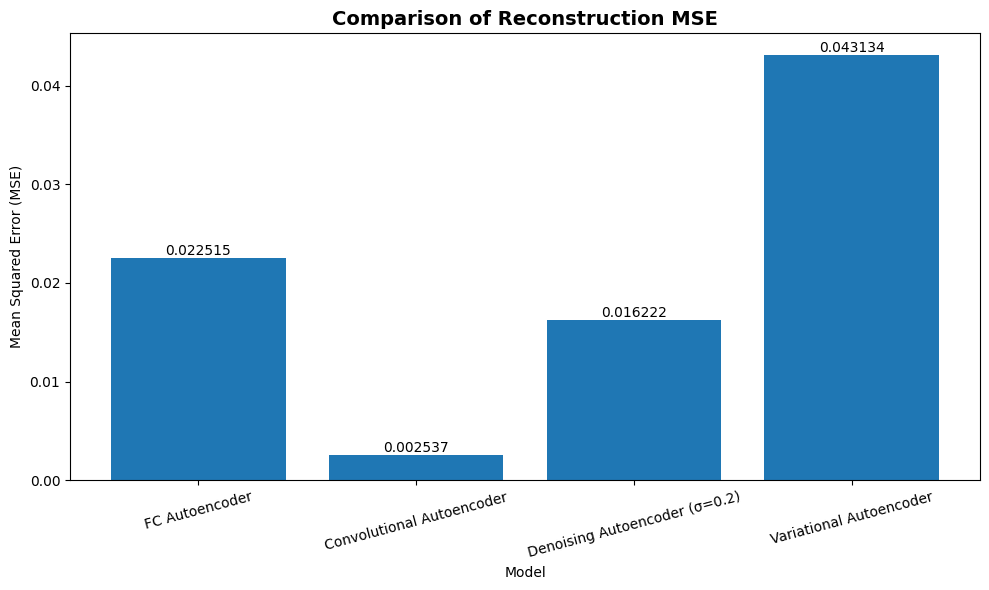

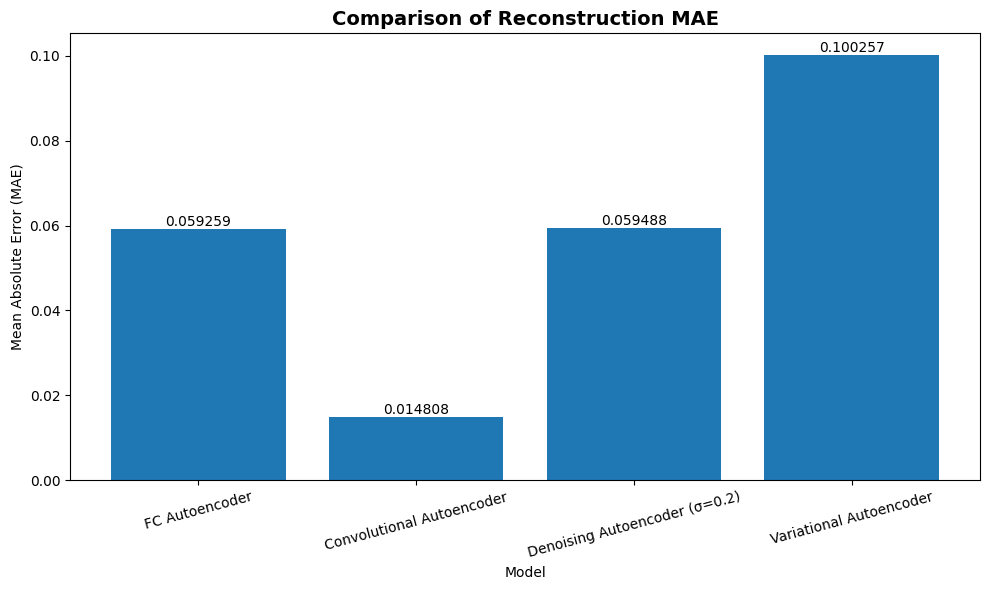

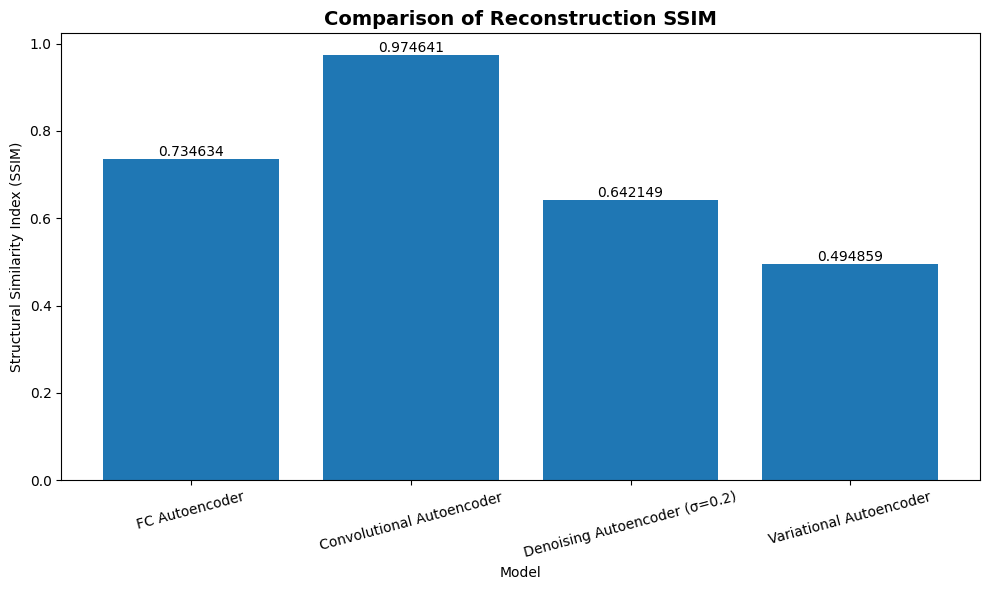


NUMERICAL COMPARISON


,Model,MSE,MAE,SSIM,Parameters
0,FC Autoencoder,0.022515,0.059259,0.734634,"211,040"
1,Convolutional Autoencoder,0.002537,0.014808,0.974641,"74,497"
2,Denoising Autoencoder (σ=0.2),0.016222,0.059488,0.642149,"74,497"
3,Variational Autoencoder,0.043134,0.100257,0.494859,"485,957"



Comparison plots generated successfully.


In [65]:
# ============================================================
# FINAL COMPARISON PLOTS
# FC-AE vs CAE vs Denoising AE vs VAE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

# ------------------------------------------------------------
# Extract results
# ------------------------------------------------------------

models = final_results["Model"].tolist()

mse_values = final_results["MSE"].values
mae_values = final_results["MAE"].values
ssim_values = final_results["SSIM"].values


# ============================================================
# 1. MSE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(models, mse_values)

plt.title("Comparison of Reconstruction MSE",
          fontsize=14, fontweight="bold")

plt.xlabel("Model")
plt.ylabel("Mean Squared Error (MSE)")

plt.xticks(rotation=15)

# Display values above bars
for bar, value in zip(bars, mse_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ============================================================
# 2. MAE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(models, mae_values)

plt.title("Comparison of Reconstruction MAE",
          fontsize=14, fontweight="bold")

plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")

plt.xticks(rotation=15)

for bar, value in zip(bars, mae_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ============================================================
# 3. SSIM COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(models, ssim_values)

plt.title("Comparison of Reconstruction SSIM",
          fontsize=14, fontweight="bold")

plt.xlabel("Model")
plt.ylabel("Structural Similarity Index (SSIM)")

plt.xticks(rotation=15)

for bar, value in zip(bars, ssim_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ============================================================
# 4. PRINT NUMERICAL COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("NUMERICAL COMPARISON")
print("=" * 80)

comparison_display = final_results[
    ["Model", "MSE", "MAE", "SSIM", "Parameters"]
].copy()

display(
    comparison_display.style.format({
        "MSE": "{:.6f}",
        "MAE": "{:.6f}",
        "SSIM": "{:.6f}",
        "Parameters": "{:,.0f}"
    })
)

print("\nComparison plots generated successfully.")

In [67]:
# ============================================================
# LATENT DIMENSION STUDY — CORRECTED VERSION
# dz = 2, 8, 16, 32
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras import layers, Model
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity

print("=" * 80)
print("VAE LATENT DIMENSION STUDY")
print("=" * 80)

latent_dimensions = [2, 8, 16, 32]

latent_results = []


# ============================================================
# BUILD VAE
# ============================================================

def build_vae_for_latent_dimension(latent_dim):

    # --------------------------------------------------------
    # Encoder
    # --------------------------------------------------------

    encoder_input = layers.Input(
        shape=(784,)
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(encoder_input)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    z_mean = layers.Dense(
        latent_dim,
        name="z_mean"
    )(x)

    z_log_var = layers.Dense(
        latent_dim,
        name="z_log_var"
    )(x)

    def sampling(args):

        mean, log_var = args

        epsilon = tf.random.normal(
            shape=tf.shape(mean)
        )

        return (
            mean
            + tf.exp(0.5 * log_var) * epsilon
        )

    z = layers.Lambda(
        sampling,
        name="sampling"
    )([z_mean, z_log_var])

    encoder_model = Model(
        encoder_input,
        [z_mean, z_log_var, z],
        name=f"Encoder_dz_{latent_dim}"
    )


    # --------------------------------------------------------
    # Decoder
    # --------------------------------------------------------

    decoder_input = layers.Input(
        shape=(latent_dim,)
    )

    y = layers.Dense(
        32,
        activation="relu"
    )(decoder_input)

    y = layers.Dense(
        128,
        activation="relu"
    )(y)

    decoder_output = layers.Dense(
        784,
        activation="sigmoid"
    )(y)

    decoder_model = Model(
        decoder_input,
        decoder_output,
        name=f"Decoder_dz_{latent_dim}"
    )


    # --------------------------------------------------------
    # Custom VAE
    # --------------------------------------------------------

    class SimpleVAE(Model):

        def __init__(
            self,
            encoder,
            decoder,
            beta=1.0
        ):

            super().__init__(
                name=f"VAE_dz_{latent_dim}"
            )

            self.encoder = encoder
            self.decoder = decoder
            self.beta = beta

        def train_step(self, data):

            # Keras may provide (x, y)
            if isinstance(data, tuple):
                data = data[0]

            with tf.GradientTape() as tape:

                mean, log_var, z = self.encoder(
                    data,
                    training=True
                )

                reconstruction = self.decoder(
                    z,
                    training=True
                )

                # Binary cross entropy
                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(
                        tf.keras.backend.binary_crossentropy(
                            data,
                            reconstruction
                        ),
                        axis=-1
                    )
                )

                # KL divergence
                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(
                        1
                        + log_var
                        - tf.square(mean)
                        - tf.exp(log_var),
                        axis=1
                    )
                )

                total_loss = (
                    reconstruction_loss
                    + self.beta * kl_loss
                )

            gradients = tape.gradient(
                total_loss,
                self.trainable_variables
            )

            self.optimizer.apply_gradients(
                zip(
                    gradients,
                    self.trainable_variables
                )
            )

            return {
                "loss": total_loss,
                "reconstruction_loss": reconstruction_loss,
                "kl_loss": kl_loss
            }

    # --------------------------------------------------------
    # Create model
    # --------------------------------------------------------

    vae_model = SimpleVAE(
        encoder_model,
        decoder_model
    )

    vae_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        )
    )

    return (
        encoder_model,
        decoder_model,
        vae_model
    )


# ============================================================
# TRAIN EACH LATENT DIMENSION
# ============================================================

for latent_dim in latent_dimensions:

    print("\n" + "-" * 80)
    print(
        f"TRAINING VAE WITH LATENT DIMENSION = {latent_dim}"
    )
    print("-" * 80)

    start_time = time.time()


    # --------------------------------------------------------
    # Build
    # --------------------------------------------------------

    encoder_temp, decoder_temp, vae_temp = \
        build_vae_for_latent_dimension(latent_dim)


    # --------------------------------------------------------
    # Train
    #
    # IMPORTANT:
    # No validation_data here.
    # This prevents Keras from calling SimpleVAE.call().
    # --------------------------------------------------------

    history_temp = vae_temp.fit(
        x_train_flat,
        epochs=20,
        batch_size=128,
        verbose=1
    )


    training_time = (
        time.time() - start_time
    )


    # --------------------------------------------------------
    # Encode test data
    # --------------------------------------------------------

    z_mean_test, z_log_var_test, z_test = \
        encoder_temp.predict(
            x_test_flat,
            verbose=0
        )


    # --------------------------------------------------------
    # Decode test data
    # --------------------------------------------------------

    reconstructed_temp = \
        decoder_temp.predict(
            z_test,
            verbose=0
        )


    # --------------------------------------------------------
    # MSE
    # --------------------------------------------------------

    mse_temp = mean_squared_error(
        x_test_flat.flatten(),
        reconstructed_temp.flatten()
    )


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae_temp = mean_absolute_error(
        x_test_flat.flatten(),
        reconstructed_temp.flatten()
    )


    # --------------------------------------------------------
    # SSIM
    # --------------------------------------------------------

    ssim_values_temp = []

    for i in range(
        len(x_test_flat)
    ):

        score = structural_similarity(
            x_test_flat[i].reshape(
                28,
                28
            ),
            reconstructed_temp[i].reshape(
                28,
                28
            ),
            data_range=1.0
        )

        ssim_values_temp.append(
            score
        )

    ssim_temp = np.mean(
        ssim_values_temp
    )


    # --------------------------------------------------------
    # Parameter count
    # --------------------------------------------------------

    parameter_count = (
        encoder_temp.count_params()
        +
        decoder_temp.count_params()
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    latent_results.append({

        "Latent Dimension":
            latent_dim,

        "MSE":
            mse_temp,

        "MAE":
            mae_temp,

        "SSIM":
            ssim_temp,

        "Parameters":
            parameter_count,

        "Training Time (sec)":
            training_time
    })


    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print("\nRESULTS")
    print("=" * 50)

    print(
        f"Latent Dimension : {latent_dim}"
    )

    print(
        f"MSE              : {mse_temp:.6f}"
    )

    print(
        f"MAE              : {mae_temp:.6f}"
    )

    print(
        f"SSIM             : {ssim_temp:.6f}"
    )

    print(
        f"Parameters       : {parameter_count:,}"
    )

    print(
        f"Training Time    : {training_time:.2f} sec"
    )


# ============================================================
# RESULTS TABLE
# ============================================================

latent_results_df = pd.DataFrame(
    latent_results
)


print("\n")
print("=" * 80)
print("LATENT DIMENSION STUDY RESULTS")
print("=" * 80)

display(
    latent_results_df.style.format({

        "MSE":
            "{:.6f}",

        "MAE":
            "{:.6f}",

        "SSIM":
            "{:.6f}",

        "Parameters":
            "{:,.0f}",

        "Training Time (sec)":
            "{:.2f}"
    })
)

VAE LATENT DIMENSION STUDY

--------------------------------------------------------------------------------
TRAINING VAE WITH LATENT DIMENSION = 2
--------------------------------------------------------------------------------
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - kl_loss: 7.6991 - loss: 214.4246 - reconstruction_loss: 206.7254 
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 4.9178 - loss: 202.6770 - reconstruction_loss: 197.7592
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 4.5684 - loss: 194.3848 - reconstruction_loss: 189.8165
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 4.8420 - loss: 189.6341 - reconstruction_loss: 184.7921
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 4.4708 - loss: 184.4548 - reconstruction_loss: 179.9840
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 4.4038 - loss: 183.2958 - reconstruction_loss: 178.8921
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 

,Latent Dimension,MSE,MAE,SSIM,Parameters,Training Time (sec)
0,2,0.048060,0.112089,0.416966,"210,196",26.57
1,8,0.031502,0.078545,0.624622,"210,784",23.64
2,16,0.027183,0.069233,0.668263,"211,568",22.44
3,32,0.028791,0.072354,0.652213,"213,136",23.91


LATENT DIMENSION ANALYSIS


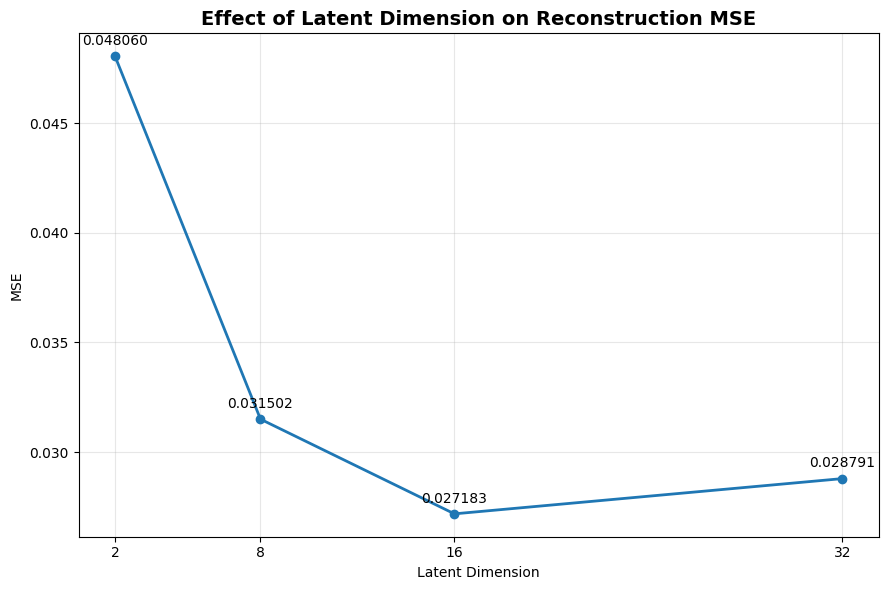

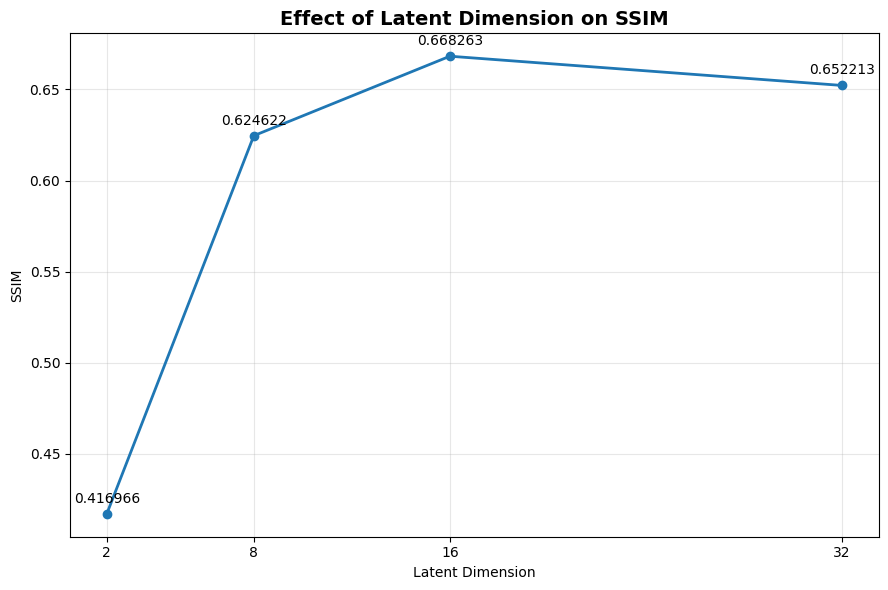

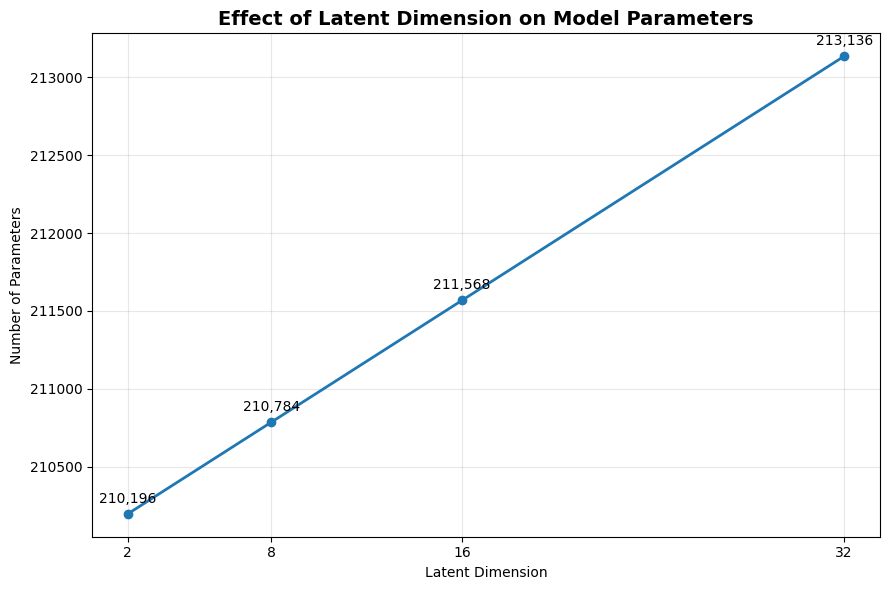


FINAL LATENT DIMENSION RESULTS


,Latent Dimension,MSE,MAE,SSIM,Parameters,Training Time (sec)
0,2,0.048060,0.112089,0.416966,"210,196",26.57
1,8,0.031502,0.078545,0.624622,"210,784",23.64
2,16,0.027183,0.069233,0.668263,"211,568",22.44
3,32,0.028791,0.072354,0.652213,"213,136",23.91



Latent-dimension analysis completed successfully.


In [68]:
# ============================================================
# LATENT DIMENSION STUDY — COMPARISON PLOTS
# ============================================================

import matplotlib.pyplot as plt

print("=" * 80)
print("LATENT DIMENSION ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Extract values
# ------------------------------------------------------------

latent_dims = latent_results_df["Latent Dimension"].values
mse_values = latent_results_df["MSE"].values
ssim_values = latent_results_df["SSIM"].values
parameter_values = latent_results_df["Parameters"].values


# ============================================================
# 1. LATENT DIMENSION vs MSE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    latent_dims,
    mse_values,
    marker="o",
    linewidth=2
)

for x, y in zip(latent_dims, mse_values):
    plt.annotate(
        f"{y:.6f}",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.title(
    "Effect of Latent Dimension on Reconstruction MSE",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Latent Dimension")
plt.ylabel("MSE")

plt.xticks(latent_dims)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 2. LATENT DIMENSION vs SSIM
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    latent_dims,
    ssim_values,
    marker="o",
    linewidth=2
)

for x, y in zip(latent_dims, ssim_values):
    plt.annotate(
        f"{y:.6f}",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.title(
    "Effect of Latent Dimension on SSIM",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Latent Dimension")
plt.ylabel("SSIM")

plt.xticks(latent_dims)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 3. LATENT DIMENSION vs PARAMETERS
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    latent_dims,
    parameter_values,
    marker="o",
    linewidth=2
)

for x, y in zip(latent_dims, parameter_values):
    plt.annotate(
        f"{y:,}",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.title(
    "Effect of Latent Dimension on Model Parameters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Latent Dimension")
plt.ylabel("Number of Parameters")

plt.xticks(latent_dims)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 4. FINAL LATENT-DIMENSION TABLE
# ============================================================

print("\n" + "=" * 80)
print("FINAL LATENT DIMENSION RESULTS")
print("=" * 80)

display(
    latent_results_df.style.format({
        "MSE": "{:.6f}",
        "MAE": "{:.6f}",
        "SSIM": "{:.6f}",
        "Parameters": "{:,.0f}",
        "Training Time (sec)": "{:.2f}"
    })
)

print("\nLatent-dimension analysis completed successfully.")